In [1]:
import importlib.util
import subprocess
import sys

for mod, pkg in [
    ("tacoreader", "tacoreader>=2.4"),
    ("rasterio", "rasterio"),
    ("segmentation_models_pytorch", "segmentation-models-pytorch"),
    ("timm", "timm"),
    ("huggingface_hub", "huggingface_hub"),
    ("psutil", "psutil"),
    ("sklearn", "scikit-learn"),
]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

In [1]:
import datetime as dt
import json
import math
import os
import random
import shutil
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import rasterio
import segmentation_models_pytorch as smp
import tacoreader
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_dilation, map_coordinates
from torch.utils.data import ConcatDataset, DataLoader, Dataset

tacoreader.use("pandas")
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
AMP_DTYPE = (
    torch.bfloat16
    if (DEVICE == "cuda" and torch.cuda.is_bf16_supported())
    else torch.float16
)
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.0f} GB | amp {AMP_DTYPE}")
print(
    f"CPUs: {os.cpu_count()} | RAM: {psutil.virtual_memory().total/1e9:.0f} GB | torch {torch.__version__} | smp {smp.__version__}"
)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA A100-SXM4-40GB MIG 7g.40gb | 42 GB | amp torch.bfloat16
CPUs: 256 | RAM: 1082 GB | torch 2.11.0a0+eb65b36914.nv26.02 | smp 0.5.0


In [2]:
QUICK_RUN = False
if os.environ.get("VAYU_QUICK"):
    QUICK_RUN = bool(int(os.environ["VAYU_QUICK"]))
MOCK_ROOT = os.environ.get("VAYU_MOCK_ROOT")  # offline testing only

BASE = (
    Path("/content")
    if Path("/content").exists()
    else Path(os.environ.get("VAYU_BASE", "./vayu_work"))
)
RAW_DIR = Path(MOCK_ROOT) if MOCK_ROOT else BASE / "methaneset"
CACHE_DIR = Path(os.environ.get("VAYU_CACHE", BASE / "vayu_cache"))
OUT_DIR = Path(os.environ.get("VAYU_OUT", BASE / "vayunetra_out"))
for d in (RAW_DIR, CACHE_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

HF_REPO, FINETUNE, BANK = (
    "tacofoundation/methaneset",
    "methaneset-s2-finetune",
    "methaneset-bank",
)
# Pretrained encoder: "ssl4eo_moco" (default), "ssl4eo_dino", or "none" (random init, for ablation)
PRETRAINED = os.environ.get("VAYU_PRETRAINED", "ssl4eo_moco")
WEIGHTS = {
    "ssl4eo_moco": (
        "torchgeo/resnet50_sentinel2_all_moco",
        "resnet50_sentinel2_all_moco-df8b932e.pth",
    ),
    "ssl4eo_dino": (
        "torchgeo/resnet50_sentinel2_all_dino",
        "resnet50_sentinel2_all_dino-d6c330e9.pth",
    ),
}

CHIP, CROP, PAD, PIX_M = (
    200,
    192,
    12,
    10.0,
)  # chips 200 px @10 m; train crops 192; eval pads to 224
N_EXTRA = 4  # extra input channels beyond the 13 bands
BATCH = int(os.environ.get("VAYU_BATCH", 64))  # 64 fits an A100 40GB in bf16 at 192x192
NW = min(12, os.cpu_count() or 4)
EPOCHS_WARM, EPOCHS_FT = (1, 2) if QUICK_RUN else (3, 30)
if os.environ.get("VAYU_EPOCHS"):
    EPOCHS_WARM, EPOCHS_FT = map(int, os.environ["VAYU_EPOCHS"].split(","))
LR_DEC, LR_ENC = 1e-3, 1e-4
MAX_SAMPLES = 300 if QUICK_RUN else None
COUNTRIES = (
    [
        "Oman",
        "Venezuela",
        "Jordan",
        "Argentina",
        "China",
        "Bahrain",
        "Kuwait",
        "Saudi_Arabia",
        "Egypt",
        "Yemen",
    ]
    if QUICK_RUN
    else None
)
BANK_PARTS = ["methaneset-bank_part0002.tacozip"] if QUICK_RUN else None
BANK_PRELOAD = 800 if QUICK_RUN else 6000
LABEL_K, MIN_PLUME_PX = 1.0, 20
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(
    f"RAW {RAW_DIR} | CACHE {CACHE_DIR} | OUT {OUT_DIR} | pretrained={PRETRAINED} | quick={QUICK_RUN}"
)
print("free disk GB:", round(shutil.disk_usage(CACHE_DIR).free / 1e9))

RAW vayu_work/methaneset | CACHE vayu_work/vayu_cache | OUT vayu_work/vayunetra_out | pretrained=ssl4eo_moco | quick=False
free disk GB: 1092


In [4]:
from huggingface_hub import hf_hub_download, snapshot_download

if not MOCK_ROOT:
    pats = [
        f"{FINETUNE}/.tacocat/*",
        f"{BANK}/.tacocat/*",
        "integrated_transmittances.json",
    ]
    pats += (
        [f"{FINETUNE}/{FINETUNE}_{c}.tacozip" for c in COUNTRIES]
        if COUNTRIES
        else [f"{FINETUNE}/*.tacozip"]
    )
    pats += [f"{BANK}/{p}" for p in BANK_PARTS] if BANK_PARTS else [f"{BANK}/*.tacozip"]
    t0 = time.time()
    snapshot_download(
        HF_REPO,
        repo_type="dataset",
        allow_patterns=pats,
        local_dir=str(RAW_DIR),
        max_workers=16,
    )
    print(f"MethaneSET downloaded in {time.time()-t0:.0f}s")
WEIGHT_PATH = os.environ.get("VAYU_WEIGHTS")
if not WEIGHT_PATH and PRETRAINED in WEIGHTS:
    WEIGHT_PATH = hf_hub_download(
        WEIGHTS[PRETRAINED][0], WEIGHTS[PRETRAINED][1], local_dir=str(BASE / "weights")
    )
print("pretrained weights:", WEIGHT_PATH)
for p in sorted(RAW_DIR.rglob("*.tacozip"))[:30]:
    print(f"  {p.stat().st_size/1e9:6.2f} GB  {p.name}")

Fetching ... files: 28it [00:00, 3324.38it/s]


MethaneSET downloaded in 5s
pretrained weights: vayu_work/weights/resnet50_sentinel2_all_moco-df8b932e.pth
    4.33 GB  methaneset-bank_part0001.tacozip
    0.62 GB  methaneset-bank_part0002.tacozip
    1.84 GB  methaneset-s2-finetune_Algeria.tacozip
    0.01 GB  methaneset-s2-finetune_Argentina.tacozip
    0.04 GB  methaneset-s2-finetune_Bahrain.tacozip
    0.01 GB  methaneset-s2-finetune_China.tacozip
    0.05 GB  methaneset-s2-finetune_Egypt.tacozip
    0.09 GB  methaneset-s2-finetune_Iran_(Islamic_Republic_of).tacozip
    0.06 GB  methaneset-s2-finetune_Iraq.tacozip
    0.00 GB  methaneset-s2-finetune_Jordan.tacozip
    0.50 GB  methaneset-s2-finetune_Kazakhstan.tacozip
    0.03 GB  methaneset-s2-finetune_Kuwait.tacozip
    0.25 GB  methaneset-s2-finetune_Libya.tacozip
    0.00 GB  methaneset-s2-finetune_Oman.tacozip
    0.00 GB  methaneset-s2-finetune_Russian_Federation.tacozip
    0.04 GB  methaneset-s2-finetune_Saudi_Arabia.tacozip
    0.09 GB  methaneset-s2-finetune_Syrian_Arab

In [5]:
ds = tacoreader.load(str(RAW_DIR / FINETUNE / ".tacocat"))
meta_all = ds.data.to_pandas().drop(columns=["internal:gdal_vsi"], errors="ignore")
print("samples:", len(meta_all))
for c in ["target:sensor", "stac:tensor_shape", "split", "site:country"]:
    if c in meta_all:
        print(f"\n{c}:\n" + meta_all[c].value_counts().head(8).to_string())
print(
    "\nMARS emission rate (kg/h):\n"
    + meta_all["detection:ch4_fluxrate"].describe().round(0).to_string()
)

samples: 3552

target:sensor:
target:sensor
S2A    1899
S2B    1652
S2C       1

stac:tensor_shape:
stac:tensor_shape
[ 13 200 200]    3552

split:
split
train         2318
test          1047
validation     187

site:country:
site:country
Turkmenistan                  1604
Algeria                       1052
Kazakhstan                     272
Libya                          146
United States of America       119
Yemen                          119
Syrian Arab Republic            51
Iran (Islamic Republic of)      46

MARS emission rate (kg/h):
count      3552.0
mean       6315.0
std        8108.0
min         327.0
25%        2461.0
50%        4144.0
75%        7361.0
max      217937.0


In [6]:
from tqdm.auto import tqdm

rows = []
for i in tqdm(range(len(meta_all)), desc="indexing"):
    ch = ds.read(i)
    ch = ch.to_pandas() if hasattr(ch, "to_pandas") else ch.data.to_pandas()
    rows += [
        (meta_all.iloc[i]["id"], leaf, vsi)
        for leaf, vsi in zip(ch["id"], ch["internal:gdal_vsi"])
    ]
paths = pd.DataFrame(rows, columns=["sid", "leaf", "vsi"]).pivot(
    index="sid", columns="leaf", values="vsi"
)
meta = meta_all.drop_duplicates("id").set_index("id").loc[paths.index].reset_index()
if COUNTRIES and not MOCK_ROOT:
    have = {p.name for p in (RAW_DIR / FINETUNE).glob("*.tacozip")}
    ok = paths["target"].apply(lambda v: any(z in v for z in have)).values
    paths, meta = paths[ok], meta[ok].reset_index(drop=True)
if MAX_SAMPLES and len(paths) > MAX_SAMPLES:
    sel = np.sort(
        np.random.default_rng(SEED).choice(len(paths), MAX_SAMPLES, replace=False)
    )
    paths, meta = paths.iloc[sel], meta.iloc[sel].reset_index(drop=True)
N = len(paths)
print("indexed samples:", N, "| leaves:", list(paths.columns))


def read(path, bands=None):
    with rasterio.open(path) as src:
        return (src.read(bands) if bands else src.read()).astype("float32")

indexing: 100%|██████████| 3552/3552 [02:51<00:00, 20.67it/s]


indexed samples: 3552 | leaves: ['bg0', 'bg1', 'bg2', 'bg3', 'ch4', 'dem', 'plume', 'target']


In [7]:
with rasterio.open(paths.iloc[0]["target"]) as s:
    NB, DTYPE = s.count, s.dtypes[0]
assert NB == 13, f"expected 13 Sentinel-2 bands, got {NB}"
B = dict(
    blue=1, green=2, red=3, nir=8, swir1=11, swir2=12
)  # 0-based, L1C order B1..B8,B8A,B9..B12
CUTOFF = dt.date(2022, 1, 25)


def to_date(x):
    try:
        return dt.date.fromisoformat(str(x)[:10])
    except Exception:
        return None


SCENE_DATE_COLS = ["stac:time_start", "bg:date0", "bg:date1", "bg:date2", "bg:date3"]
dates = pd.DataFrame(
    {c: meta[c].map(to_date) if c in meta else None for c in SCENE_DATE_COLS}
)
probe = np.random.default_rng(1).choice(N, min(80, N), replace=False)
lows = {"pre": [], "post": []}
for i in probe:
    d = dates.iloc[i]["stac:time_start"]
    if d is None:
        continue
    x = read(paths.iloc[i]["target"], [2, 3, 4])  # B2,B3,B4
    lows["post" if d >= CUTOFF else "pre"].append(np.percentile(x, 1))
pre, post = np.median(lows["pre"]) if lows["pre"] else np.nan, (
    np.median(lows["post"]) if lows["post"] else np.nan
)
APPLY_OFFSET = bool(np.isfinite(pre) and np.isfinite(post) and post - pre > 600)
print(
    f"dtype {DTYPE} | darkest-pixel DN (visible bands): before 2022-01-25 = {pre:.0f}, after = {post:.0f}"
)
print(
    ">>> subtracting 1000 DN from post-2022 scenes"
    if APPLY_OFFSET
    else ">>> no offset detected: data already harmonized"
)


def to_reflectance(x, date):
    if APPLY_OFFSET and date is not None and date >= CUTOFF:
        x = x - 1000.0
    return np.clip(x, 0, None) / 10000.0

dtype uint16 | darkest-pixel DN (visible bands): before 2022-01-25 = 1871, after = 1734
>>> no offset detected: data already harmonized


In [8]:
LUT = json.load(open(RAW_DIR / "integrated_transmittances.json"))
AMF_ARR, MR, BGPPB = (
    np.array(LUT["amf_arr"]),
    np.array(LUT["mr_ch4_arr"]),
    float(LUT["background_concentration"]),
)
LUT_KEYS = [k for k in LUT if isinstance(LUT[k], dict)]


def lut_key(sensor):
    s = str(sensor).upper()
    return next((k for k in LUT_KEYS if k in s), "S2A")


def amf_of(sza, vza=0.0):
    return float(
        np.clip(
            1 / np.cos(np.radians(sza)) + 1 / np.cos(np.radians(vza)),
            AMF_ARR.min(),
            AMF_ARR.max(),
        )
    )


def band_ratios(enh_ppb, key, amf):
    i = int(np.argmin(np.abs(AMF_ARR - amf)))
    mr = MR[i]
    t11, t12 = np.array(LUT[key]["transmittance_b11"][i]), np.array(
        LUT[key]["transmittance_b12"][i]
    )
    x = BGPPB + enh_ppb
    return np.interp(x, mr, t11) / np.interp(BGPPB, mr, t11), np.interp(
        x, mr, t12
    ) / np.interp(BGPPB, mr, t12)


def mbsp(r11, r12, v):
    a, b = r11[v], r12[v]
    c = float((a * b).sum() / max((b * b).sum(), 1e-12))
    return (c * r12 - r11) / np.maximum(r11, 1e-6)


def mbmp(t11, t12, refs):
    """Methane-positive MBMP: median over references of (MBSP_ref - MBSP_target)."""
    v = (t11 > 0) & (t12 > 0)
    st = mbsp(t11, t12, v)
    m = np.nanmedian(
        np.stack([mbsp(r11, r12, v & (r11 > 0) & (r12 > 0)) - st for r11, r12 in refs]),
        0,
    )
    m[~v] = 0
    return np.nan_to_num(m).astype("float32")


def robust_sigma(x):
    x = x[np.isfinite(x)]
    return float(1.4826 * np.median(np.abs(x - np.median(x)))) + 1e-6


meta["lut_key"] = meta.get("target:sensor", pd.Series(["S2A"] * N)).map(lut_key)
print(
    "LUT sensors:",
    LUT_KEYS,
    "| per-sample keys:",
    meta["lut_key"].value_counts().to_dict(),
)

LUT sensors: ['S2A', 'S2B', 'S2C', 'LC08', 'LC09', 'LE07', 'LT04', 'LT05'] | per-sample keys: {'S2A': 1899, 'S2B': 1652, 'S2C': 1}


In [9]:
def fit(a, n=CHIP):
    h, w = a.shape[-2:]
    if (h, w) == (n, n):
        return a
    out = np.zeros(a.shape[:-2] + (n, n), a.dtype)
    hh, ww = min(h, n), min(w, n)
    y0, x0, Y0, X0 = (h - hh) // 2, (w - ww) // 2, (n - hh) // 2, (n - ww) // 2
    out[..., Y0 : Y0 + hh, X0 : X0 + ww] = a[..., y0 : y0 + hh, x0 : x0 + ww]
    return out


SCENES = ["target", "bg0", "bg1", "bg2", "bg3"]
spec = {
    "img": ((N, 5, 13, CHIP, CHIP), "float16"),
    "mask": ((N, CHIP, CHIP), "uint8"),
    "ch4": ((N, CHIP, CHIP), "float16"),
}
flag = CACHE_DIR / f"ready_{N}_{int(APPLY_OFFSET)}.json"
if not flag.exists():
    MM = {
        k: np.lib.format.open_memmap(
            CACHE_DIR / f"{k}.npy", mode="w+", dtype=d, shape=s
        )
        for k, (s, d) in spec.items()
    }
    bad = []

    def work(i):
        P = paths.iloc[i]
        try:
            for j, (sc, dc) in enumerate(zip(SCENES, SCENE_DATE_COLS)):
                MM["img"][i, j] = fit(
                    to_reflectance(read(P[sc]), dates.iloc[i][dc])
                ).astype("float16")
            MM["mask"][i] = fit((read(P["plume"])[0] > 0).astype("uint8"))
            MM["ch4"][i] = fit(read(P["ch4"])[0]).astype("float16")
        except Exception as e:
            bad.append((int(i), repr(e)[:120]))

    t0 = time.time()
    with ThreadPoolExecutor(16) as ex:
        list(tqdm(ex.map(work, range(N)), total=N, desc="caching"))
    for v in MM.values():
        v.flush()
    json.dump({"bad": bad}, open(flag, "w"))
    print(f"cache built in {time.time()-t0:.0f}s | failures: {len(bad)}")
BAD = {b[0] for b in json.load(open(flag))["bad"]}
size = sum((CACHE_DIR / f"{k}.npy").stat().st_size for k in spec)
IN_RAM = psutil.virtual_memory().available > 1.4 * size
MM = {
    k: (
        np.load(CACHE_DIR / f"{k}.npy")
        if IN_RAM
        else np.load(CACHE_DIR / f"{k}.npy", mmap_mode="r")
    )
    for k in spec
}
print(f"cache {size/1e9:.1f} GB | loaded into RAM: {IN_RAM}")

caching:   0%|          | 1/3552 [00:00<06:15,  9.46it/s]/tmp/ipykernel_3546/290136957.py:19: RuntimeWarning: overflow encountered in cast
  MM["ch4"][i] = fit(read(P["ch4"])[0]).astype("float16")
caching: 100%|██████████| 3552/3552 [00:51<00:00, 69.13it/s]


cache built in 59s | failures: 0
cache 18.9 GB | loaded into RAM: True


In [18]:
split = (
    meta.get("split", pd.Series(["train"] * N))
    .astype(str)
    .str.lower()
    .replace({"val": "validation"})
    .values.copy()
)
locs = (
    meta.get("site:location_name", pd.Series(np.arange(N).astype(str)))
    .astype(str)
    .values
)
tr_locs = np.unique(locs[split == "train"])
move = set(
    np.random.default_rng(SEED).choice(
        tr_locs, max(1, int(0.1 * len(tr_locs))), replace=False
    )
)
split[(split == "train") & np.isin(locs, list(move))] = "validation"
SPLIT = {
    s: [i for i in np.where(split == s)[0] if i not in BAD]
    for s in ["train", "validation", "test"]
}
TRAIN, VAL = SPLIT["train"], SPLIT["validation"] or SPLIT["train"][:50]
TEST = SPLIT["test"] or VAL
print(
    {k: len(v) for k, v in SPLIT.items()},
    f"| {len(move)} train sites moved to validation",
)


def geom(i):
    r = meta.iloc[i]
    g = lambda c, d: float(r[c]) if c in r and pd.notna(r[c]) else d
    sza, vza = g("target:sza", 35.0), g("target:vza", 0.0)
    return dict(
        sza=sza,
        vza=vza,
        amf=amf_of(sza, vza),
        key=r["lut_key"],
        u=g("meteo:wind_u", 0.0),
        v=g("meteo:wind_v", 0.0),
        elev=g("geoenrich:elevation", 0.0),
    )


GEOM = [geom(i) for i in range(N)]

{'train': 2096, 'validation': 409, 'test': 1047} | 16 train sites moved to validation


In [19]:
bank_ds = tacoreader.load(str(RAW_DIR / BANK / ".tacocat"))
bank = bank_ds.data.to_pandas()
have_b = {p.name for p in (RAW_DIR / BANK).glob("*.tacozip")}
bank = bank[
    bank["internal:gdal_vsi"].apply(lambda v: any(z in v for z in have_b))
].reset_index(drop=True)
bsel = np.random.default_rng(SEED).choice(
    len(bank), min(BANK_PRELOAD, len(bank)), replace=False
)


def _lb(j):
    r = bank.iloc[j]
    return read(r["internal:gdal_vsi"])[0], (
        float(r["methane:wind_speed"]),
        float(r["sun:sza"]),
        float(r["array:source_col"]),
        float(r["array:source_row"]),
    )


with ThreadPoolExecutor(16) as ex:
    BL = list(ex.map(_lb, bsel))
BANK_IMG = [b[0] for b in BL]
BANK_META = np.array([b[1] for b in BL])  # cols: wind, sza, src_col, src_row
print(
    f"bank plumes in RAM: {len(BANK_IMG)} ({sum(i.nbytes for i in BANK_IMG)/1e6:.0f} MB)"
)


def pick_bank(rng, sza, ws=None):
    c = np.where(np.abs(BANK_META[:, 1] - sza) <= 10)[0]
    if ws and len(c):
        c2 = c[np.abs(BANK_META[c, 0] - ws) <= 1.5]
        c = c2 if len(c2) else c
    return int(rng.choice(c if len(c) else np.arange(len(BANK_IMG))))


def place_plume(j, q_kgph, theta, src_rc, n=CHIP):
    """Bank plume j (ppb @3000 kg/h, 20 m px, wind +x) -> n x n north-up 10 m grid, wind direction theta."""
    img, (_, _, sc, sr) = BANK_IMG[j], BANK_META[j]
    r, c = np.mgrid[0:n, 0:n].astype("float32")
    dx, dy = (c - src_rc[1]) * PIX_M, -(r - src_rc[0]) * PIX_M
    xp = dx * math.cos(theta) + dy * math.sin(theta)
    yp = -dx * math.sin(theta) + dy * math.cos(theta)
    return (
        map_coordinates(img, [sr - yp / 20.0, sc + xp / 20.0], order=1, cval=0.0)
        * (q_kgph / 3000.0)
    ).astype("float32")

bank plumes in RAM: 6000 (267 MB)


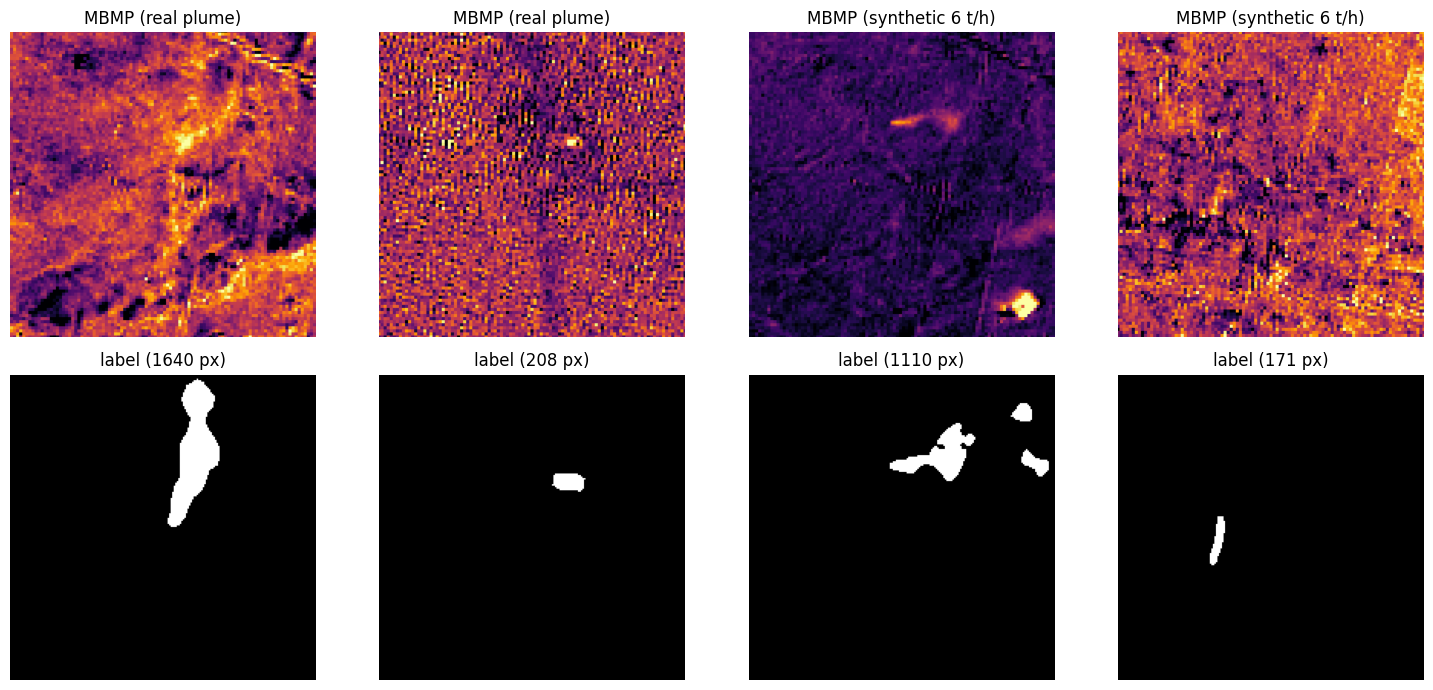

In [25]:
def make_input(img13, refs, m):
    ref = np.median(np.stack([np.stack(r) for r in refs]), 0)
    extra = [
        ref[0],
        ref[1],
        np.clip(m / 0.02, -10, 10),
        np.clip((m - np.median(m)) / robust_sigma(m), -8, 8),
    ]
    return np.concatenate([np.clip(img13, 0, 2), np.stack(extra)]).astype("float32")


def real_item(i):
    x = MM["img"][i].astype("float32")  # (5,13,H,W)
    refs = [(x[k, B["swir1"]], x[k, B["swir2"]]) for k in range(1, 5)]
    m = mbmp(x[0, B["swir1"]], x[0, B["swir2"]], refs)
    return make_input(x[0], refs, m), MM["mask"][i].astype("float32"), m


def synth_item(i, rng, inject=True, q=None, t=None):
    g = GEOM[i]
    x = MM["img"][i].astype("float32")
    t = (
        t if t is not None else int(rng.integers(1, 5))
    )  # a clean background becomes the target
    tgt = x[t].copy()
    refs = [(x[k, B["swir1"]], x[k, B["swir2"]]) for k in range(1, 5) if k != t]
    m0 = mbmp(tgt[B["swir1"]], tgt[B["swir2"]], refs)
    sigma = robust_sigma(m0)
    mask = np.zeros((CHIP, CHIP), "float32")
    info = dict(q=None, j=None, sigma=sigma)
    if not inject:
        return make_input(tgt, refs, m0), mask, m0, info
    q = q if q is not None else float(np.exp(rng.uniform(np.log(500), np.log(15000))))
    ws = float(np.hypot(g["u"], g["v"]))
    j = pick_bank(rng, g["sza"], ws or None)
    theta = (
        math.atan2(g["v"], g["u"]) + rng.normal(0, 0.5)
        if ws > 0.5
        else rng.uniform(0, 2 * math.pi)
    )
    enh = place_plume(j, q, theta, (rng.uniform(50, 150), rng.uniform(50, 150)))
    r11, r12 = band_ratios(enh, g["key"], g["amf"])
    tgt[B["swir1"]] *= r11
    tgt[B["swir2"]] *= r12
    m = mbmp(tgt[B["swir1"]], tgt[B["swir2"]], refs)
    mask = (((1 - r12 / r11) > LABEL_K * sigma) & (enh > 100)).astype("float32")
    if mask.sum() < MIN_PLUME_PX:
        mask[:] = 0
    info.update(q=q, j=j)
    return make_input(tgt, refs, m), mask, m, info


class PlumeSet(Dataset):
    def __init__(self, idx, mode, n, p_inject=0.6, train=True, seed=0):
        self.idx, self.mode, self.n, self.p, self.train, self.seed = list(idx), mode, n, p_inject, train, seed
    def __len__(self): return self.n
    def __getitem__(self, k):
        rng = np.random.default_rng(None if self.train else self.seed * 100003 + k)
        i = self.idx[rng.integers(len(self.idx))] if self.train else self.idx[k % len(self.idx)]
        x, y = real_item(i)[:2] if self.mode == "real" else synth_item(i, rng, inject=rng.random() < self.p)[:2]
        if self.train:
            y0, x0 = rng.integers(0, CHIP - CROP + 1, 2); x, y = x[:, y0:y0 + CROP, x0:x0 + CROP], y[y0:y0 + CROP, x0:x0 + CROP]
            kk = int(rng.integers(4)); x, y = np.rot90(x, kk, (1, 2)), np.rot90(y, kk)
            if rng.random() < .5: x, y = x[:, :, ::-1], y[:, ::-1]
        else:
            x = np.pad(x, ((0, 0), (PAD, PAD), (PAD, PAD)), mode="reflect"); y = np.pad(y, PAD)
        return torch.from_numpy(np.ascontiguousarray(x, dtype=np.float16)), torch.from_numpy(np.ascontiguousarray(y, dtype=np.uint8))[None]

rng = np.random.default_rng(3)
fig, ax = plt.subplots(2, 4, figsize=(15, 7))
for c in range(4):
    i = TRAIN[rng.integers(len(TRAIN))]
    if c < 2:
        xin, y, m = real_item(i)
        tt = "real plume"
    else:
        xin, y, m, info = synth_item(i, rng, q=6000)
        tt = "synthetic 6 t/h"
    ax[0, c].imshow(
        m, cmap="inferno", vmin=np.percentile(m, 2), vmax=np.percentile(m, 99.7)
    )
    ax[0, c].set_title(f"MBMP ({tt})")
    ax[1, c].imshow(y, cmap="gray")
    ax[1, c].set_title(f"label ({int(y.sum())} px)")
    for a in ax[:, c]:
        a.axis("off")
plt.tight_layout()
plt.show()

In [26]:
def build_model():
    return smp.Unet(
        "resnet50",
        encoder_weights=None,
        in_channels=13 + N_EXTRA,
        classes=1,
        decoder_attention_type="scse",
        aux_params=dict(classes=1, pooling="avg", dropout=0.2),
    )


def load_pretrained(model, path):
    sd = torch.load(path, map_location="cpu", weights_only=True)
    sd = sd.get("state_dict", sd.get("model", sd))
    sd = {
        k.replace("module.", "").replace("backbone.", "").replace("encoder.", ""): v
        for k, v in sd.items()
        if not k.startswith("fc.")
    }
    w = sd["conv1.weight"]
    assert w.shape[1] == 13, f"expected 13-band conv1, got {tuple(w.shape)}"
    sd["conv1.weight"] = torch.cat(
        [w, torch.zeros(w.shape[0], N_EXTRA, *w.shape[2:])], 1
    )
    esd = (
        model.encoder.state_dict()
    )  # smp's encoder overrides load_state_dict, so check keys ourselves
    missing = [k for k in esd if k not in sd]
    unexpected = [k for k in sd if k not in esd]
    badshape = [k for k in sd if k in esd and sd[k].shape != esd[k].shape]
    assert not missing and not badshape, (missing[:5], badshape[:5])
    model.encoder.load_state_dict(
        {k: v for k, v in sd.items() if k in esd}, strict=True
    )
    assert torch.equal(
        model.encoder.state_dict()["layer4.2.conv3.weight"], sd["layer4.2.conv3.weight"]
    ), "weights did not load"
    print(
        f"loaded {len(esd)} pretrained encoder tensors | missing 0 | ignored {len(unexpected)}"
    )


model = build_model()
if WEIGHT_PATH:
    load_pretrained(model, WEIGHT_PATH)
else:
    print("WARNING: no pretrained weights (random init)")
model = model.to(DEVICE).to(memory_format=torch.channels_last)
print("parameters: %.1f M" % (sum(p.numel() for p in model.parameters()) / 1e6))

loaded 318 pretrained encoder tensors | missing 0 | ignored 0
parameters: 33.9 M


In [29]:
def loss_fn(seg, scene, y):
    p = torch.sigmoid(seg)
    inter = (p * y).sum((1, 2, 3))
    dice = 1 - (2 * inter + 1) / (p.sum((1, 2, 3)) + y.sum((1, 2, 3)) + 1)
    bce = F.binary_cross_entropy_with_logits(seg, y, reduction="none")
    focal = ((1 - torch.exp(-bce)) ** 2 * bce).mean((1, 2, 3))
    ys = (y.sum((1, 2, 3)) >= MIN_PLUME_PX).float()
    return (dice + 10 * focal).mean() + 0.5 * F.binary_cross_entropy_with_logits(
        scene[:, 0], ys
    )


def scene_score(prob):
    flat = prob.reshape(prob.shape[0], -1)
    return torch.topk(flat, min(MIN_PLUME_PX, flat.shape[1]), 1).values.mean(1)


from torch.optim.swa_utils import AveragedModel


def _ema_avg(
    avg, cur, n
):  # decay ramps up to 0.999 so early epochs aren't dominated by the init
    d = min(0.999, (1.0 + float(n)) / (10.0 + float(n)))
    return d * avg + (1.0 - d) * cur


ema = AveragedModel(
    model, avg_fn=_ema_avg, use_buffers=True
)  # use_buffers: also average BatchNorm statistics


@torch.no_grad()
def evaluate(net, dl):
    net.eval()
    tp = fp = fn = 0
    st, sp = [], []
    for x, y in dl:
        x = (
            x.to(DEVICE, non_blocking=True)
            .float()
            .to(memory_format=torch.channels_last)
        )
        y = y.to(DEVICE).float()
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=DEVICE == "cuda"):
            seg, _ = net(x)
        p = torch.sigmoid(seg.float())
        pb = p > 0.5
        tp += (pb & (y > 0)).sum().item()
        fp += (pb & (y == 0)).sum().item()
        fn += (~pb & (y > 0)).sum().item()
        st += (y.sum((1, 2, 3)) >= MIN_PLUME_PX).cpu().tolist()
        sp += scene_score(p).cpu().tolist()
    st, sp = np.array(st, bool), np.array(sp)
    pr = sp > 0.5
    P, R = (pr & st).sum() / max(pr.sum(), 1), (pr & st).sum() / max(st.sum(), 1)
    return dict(
        iou=tp / max(tp + fp + fn, 1), P=P, R=R, f1=2 * P * R / max(P + R, 1e-9)
    )


import collections


class ThreadLoader:
    """Batches built in threads inside the main process: no /dev/shm needed."""

    def __init__(self, ds, batch, shuffle, drop_last, workers=16):
        self.ds, self.b, self.shuffle, self.drop, self.w = (
            ds,
            batch,
            shuffle,
            drop_last,
            workers,
        )

    def __len__(self):
        return len(self.ds) // self.b if self.drop else math.ceil(len(self.ds) / self.b)

    def _make(self, ids):
        items = [self.ds[int(j)] for j in ids]
        x, y = torch.stack([a for a, _ in items]), torch.stack([b for _, b in items])
        return (x.pin_memory(), y.pin_memory()) if DEVICE == "cuda" else (x, y)

    def __iter__(self):
        idx = (
            np.random.permutation(len(self.ds))
            if self.shuffle
            else np.arange(len(self.ds))
        )
        bl = [idx[i : i + self.b] for i in range(0, len(idx), self.b)][: len(self)]
        with ThreadPoolExecutor(self.w) as ex:
            q = collections.deque(ex.submit(self._make, ids) for ids in bl[: self.w])
            k = len(q)
            while q:
                out = q.popleft().result()
                if k < len(bl):
                    q.append(ex.submit(self._make, bl[k]))
                    k += 1
                yield out


def shm_free_gb():
    try:
        return shutil.disk_usage("/dev/shm").free / 1e9
    except Exception:
        return 0.0


def loaders(p_inject=0.6):
    tr = ConcatDataset(
        [
            PlumeSet(TRAIN, "real", len(TRAIN)),
            PlumeSet(TRAIN, "synth", 2 * len(TRAIN), p_inject),
        ]
    )
    va = ConcatDataset(
        [
            PlumeSet(VAL, "real", len(VAL), train=False, seed=1),
            PlumeSet(VAL, "synth", 2 * len(VAL), 0.5, train=False, seed=2),
        ]
    )
    batch_gb = (
        BATCH * (13 + N_EXTRA + 1) * (CHIP + 2 * PAD) ** 2 * 2 / 1e9
    )  # float16 batch, worst case (eval size)
    budget = int(
        0.5 * shm_free_gb() / max(batch_gb, 1e-9)
    )  # batches we can keep in /dev/shm
    mode = os.environ.get("VAYU_LOADER", "auto")
    if mode == "process" or (mode == "auto" and budget >= 8):
        nw = max(2, min(NW, budget // 4))
        kw = dict(
            num_workers=nw,
            pin_memory=DEVICE == "cuda",
            persistent_workers=False,
            prefetch_factor=2,
        )
        print(
            f"loader: {nw} worker processes (/dev/shm free {shm_free_gb():.1f} GB, {batch_gb*1e3:.0f} MB/batch)"
        )
        return DataLoader(tr, BATCH, shuffle=True, drop_last=True, **kw), DataLoader(
            va, BATCH, shuffle=False, **kw
        )
    print(f"loader: threads in the main process (/dev/shm free {shm_free_gb():.2f} GB)")
    return ThreadLoader(tr, BATCH, True, True, workers=min(16, 2 * NW)), ThreadLoader(
        va, BATCH, False, False, workers=min(16, 2 * NW)
    )


try:
    del TR_DL, VA_DL  # release old workers / shared memory if re-running
except NameError:
    pass
import gc

gc.collect()
TR_DL, VA_DL = loaders()

loader: threads in the main process (/dev/shm free 0.07 GB)


In [30]:
BEST = {"score": -1.0}
HIST = []


def run(epochs, groups, tag):
    opt = torch.optim.AdamW(groups, weight_decay=1e-4)
    scaler = torch.amp.GradScaler(
        enabled=(DEVICE == "cuda" and AMP_DTYPE == torch.float16)
    )
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=[g["lr"] for g in groups],
        total_steps=epochs * len(TR_DL),
        pct_start=0.15,
    )
    for ep in range(epochs):
        model.train()
        t0 = time.time()
        tot = 0.0
        for x, y in TR_DL:
            x = (
                x.to(DEVICE, non_blocking=True)
                .float()
                .to(memory_format=torch.channels_last)
            )
            y = y.to(DEVICE, non_blocking=True).float()
            with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=DEVICE == "cuda"):
                seg, sc = model(x)
            loss = loss_fn(seg.float(), sc.float(), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            ema.update_parameters(model)
            tot += loss.item()
        ev = evaluate(ema.module, VA_DL)
        score = ev["iou"] + ev["f1"]
        HIST.append(dict(stage=tag, epoch=ep + 1, loss=tot / len(TR_DL), **ev))
        best = score > BEST["score"]
        if best:
            BEST["score"] = score
            torch.save(ema.module.state_dict(), OUT_DIR / "best.pt")
        print(
            f"[{tag}] ep {ep+1}/{epochs} loss {tot/len(TR_DL):.3f} | val IoU {ev['iou']:.3f} scene P/R {ev['P']:.2f}/{ev['R']:.2f} | {time.time()-t0:.0f}s"
            + ("  *" if best else "")
        )

In [31]:
for n_, p_ in model.encoder.named_parameters():
    p_.requires_grad = n_.startswith("conv1")
groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": LR_DEC}]
run(EPOCHS_WARM, groups, "warm")

[warm] ep 1/3 loss 1.635 | val IoU 0.227 scene P/R 0.66/0.89 | 87s  *
[warm] ep 2/3 loss 1.380 | val IoU 0.259 scene P/R 0.65/0.91 | 58s  *
[warm] ep 3/3 loss 1.346 | val IoU 0.266 scene P/R 0.64/0.94 | 59s  *


In [57]:
# Cell 14b — Training fixes: Dice only on plume samples + detectability-aware synthetic injection
import shutil
if (OUT_DIR / "best.pt").exists() and not (OUT_DIR / "best_v1_oldloss.pt").exists():
    shutil.copy(OUT_DIR / "best.pt", OUT_DIR / "best_v1_oldloss.pt")            # keep the model behind your current pitch numbers

def loss_fn(seg, scene,  y):
    p = torch.sigmoid(seg); pos = y.sum((1, 2, 3)) >= MIN_PLUME_PX
    bce = F.binary_cross_entropy_with_logits(seg, y, reduction="none")
    focal = (0.5 * (1 - torch.exp(-bce)) ** 2 * bce).mean()                                   # balanced focal, pixel level
    if pos.any():
        pp, yy = p[pos], y[pos]; inter = (pp * yy).sum((1, 2, 3))
        dice = (1 - (2 * inter + 1) / (pp.sum((1, 2, 3)) + yy.sum((1, 2, 3)) + 1)).mean()      # Dice only where a plume exists
    else: dice = seg.new_zeros(())
    flat = seg.flatten(1); topk = torch.topk(flat, min(MIN_PLUME_PX, flat.shape[1]), 1).values.mean(1)
    det = F.binary_cross_entropy_with_logits(topk, pos.float())                                # trains the actual detection score
    return dice + 20 * focal + 1.0 * det + 0.5 * F.binary_cross_entropy_with_logits(scene[:, 0], pos.float())

if "_synth_item_orig" not in globals(): _synth_item_orig = synth_item                # safe to re-run this cell
def synth_item(i, rng, inject=True, q=None, t=None):
    """Training injections (q=None): if the plume is below the scene noise, retry 2x/4x bigger, else return the clean scene.
    Fixed-q calls (PoD, IME calibration) behave exactly as before."""
    if not inject or q is not None: return _synth_item_orig(i, rng, inject=inject, q=q, t=t)
    t = t if t is not None else int(rng.integers(1, 5)); q0 = float(np.exp(rng.uniform(np.log(500), np.log(15000))))
    for a in range(3):
        out = _synth_item_orig(i, rng, inject=True, q=q0 * 2 ** a, t=t)
        if out[1].sum() >= MIN_PLUME_PX: return out
    return _synth_item_orig(i, rng, inject=False, t=t)

def detectability(idx, qs=(500, 1000, 2000, 3000, 5000, 8000, 12000), n=60):
    rows = []
    for q in qs:
        for k in range(n):
            x, y, m, info = _synth_item_orig(idx[k % len(idx)], np.random.default_rng(90_000 + 31 * q + k), q=q)
            rows.append(dict(q=q, labelled=y.sum() >= MIN_PLUME_PX, sigma=info["sigma"]))
    return pd.DataFrame(rows).groupby("q").agg(detectable=("labelled", "mean"), noise_sigma=("sigma", "median"))
print("MethaneSET backgrounds: fraction of injected plumes above scene noise\n", detectability(VAL).round(3).to_string())

MethaneSET backgrounds: fraction of injected plumes above scene noise
        detectable  noise_sigma
q                             
500         0.067        0.006
1000        0.417        0.006
2000        0.767        0.006
3000        0.867        0.006
5000        0.983        0.006
8000        1.000        0.006
12000       1.000        0.006


In [60]:
# Cell 17c — Choose between old model, new best-val (ep 12) and new final (ep 30) on VALIDATION, threshold-free
from sklearn.metrics import roc_curve, auc
torch.save(ema.module.state_dict(), OUT_DIR / "last_ft.pt")                       # final-epoch EMA weights
CANDS = {"old (v1 loss)": "best_v1_oldloss.pt", "new best-val (ep 12)": "best.pt", "new final (ep 30)": "last_ft.pt"}
_iou = lambda p, y: (p & (y > 0)).sum() / max((p | (y > 0)).sum(), 1)
def quick_eval(path, idx):
    model.load_state_dict(torch.load(OUT_DIR / path, map_location=DEVICE)); model.eval()
    rows = collect(idx); y = np.array([r["kind"] == "plume" for r in rows]); s = np.array([r["ps"] for r in rows])
    fpr, tpr, _ = roc_curve(y, s)
    return dict(AUC=auc(fpr, tpr), recall_5=np.interp(.05, fpr, tpr), recall_10=np.interp(.10, fpr, tpr), recall_20=np.interp(.20, fpr, tpr),
                pixel_IoU=np.mean([_iou(r["prob"] > .5, r["y"]) for r in rows if r["kind"] == "plume"]))
cmp_ = pd.DataFrame({k: quick_eval(v, VAL) for k, v in CANDS.items()}).T.round(3)
print("VALIDATION (selection only):\n" + cmp_.to_string())
win = (cmp_["AUC"] + cmp_["recall_10"]).idxmax(); sel = OUT_DIR / CANDS[win]
if sel.name != "best.pt": shutil.copy(sel, OUT_DIR / "best.pt")
model.load_state_dict(torch.load(OUT_DIR / "best.pt", map_location=DEVICE)); model.eval()
print(f"selected: {win} → saved as best.pt")

scoring: 100%|██████████| 409/409 [00:57<00:00,  7.13it/s]


VALIDATION (selection only):
                        AUC  recall_5  recall_10  recall_20  pixel_IoU
old (v1 loss)         0.771     0.152      0.296      0.528      0.418
new best-val (ep 12)  0.803     0.203      0.406      0.619      0.422
new final (ep 30)     0.790     0.152      0.406      0.592      0.390
selected: new best-val (ep 12) → saved as best.pt


In [58]:
for p_ in model.parameters(): p_.requires_grad = True
enc_ids = {id(p) for p in model.encoder.parameters()}
groups = [{"params": list(model.encoder.parameters()), "lr": LR_ENC},
          {"params": [p for p in model.parameters() if id(p) not in enc_ids], "lr": LR_DEC}]
run(EPOCHS_FT, groups, "ft")
model.load_state_dict(torch.load(OUT_DIR / "best.pt", map_location=DEVICE)); model.eval()
pd.DataFrame(HIST).to_csv(OUT_DIR / "history.csv", index=False); print("best val score:", round(BEST["score"], 3))

[ft] ep 1/30 loss 1.455 | val IoU 0.339 scene P/R 0.73/0.93 | 58s  *
[ft] ep 2/30 loss 1.444 | val IoU 0.339 scene P/R 0.72/0.93 | 58s
[ft] ep 3/30 loss 1.483 | val IoU 0.329 scene P/R 0.72/0.95 | 57s
[ft] ep 4/30 loss 1.501 | val IoU 0.329 scene P/R 0.72/0.95 | 58s
[ft] ep 5/30 loss 1.553 | val IoU 0.321 scene P/R 0.72/0.95 | 57s
[ft] ep 6/30 loss 1.566 | val IoU 0.327 scene P/R 0.72/0.95 | 56s
[ft] ep 7/30 loss 1.544 | val IoU 0.326 scene P/R 0.72/0.95 | 58s
[ft] ep 8/30 loss 1.524 | val IoU 0.322 scene P/R 0.71/0.96 | 57s
[ft] ep 9/30 loss 1.510 | val IoU 0.327 scene P/R 0.71/0.96 | 57s
[ft] ep 10/30 loss 1.497 | val IoU 0.333 scene P/R 0.72/0.95 | 58s
[ft] ep 11/30 loss 1.497 | val IoU 0.335 scene P/R 0.72/0.96 | 58s
[ft] ep 12/30 loss 1.464 | val IoU 0.336 scene P/R 0.72/0.96 | 58s  *
[ft] ep 13/30 loss 1.484 | val IoU 0.337 scene P/R 0.71/0.96 | 58s
[ft] ep 14/30 loss 1.463 | val IoU 0.338 scene P/R 0.72/0.94 | 58s
[ft] ep 15/30 loss 1.452 | val IoU 0.338 scene P/R 0.72/0.94 | 57

In [59]:
# Continue fine-tuning from best.pt for 25 more epochs (31 -> 55) at a lower learning rate
EXTRA_EPOCHS = 25
model.load_state_dict(torch.load(OUT_DIR / "best.pt", map_location=DEVICE))
for p_ in model.parameters(): p_.requires_grad = True
ema = AveragedModel(model, avg_fn=_ema_avg, use_buffers=True)          # fresh EMA starting from best.pt
enc_ids = {id(p) for p in model.encoder.parameters()}
groups = [{"params": list(model.encoder.parameters()), "lr": LR_ENC * 0.3},
          {"params": [p for p in model.parameters() if id(p) not in enc_ids], "lr": LR_DEC * 0.3}]
run(EXTRA_EPOCHS, groups, "ft2")
model.load_state_dict(torch.load(OUT_DIR / "best.pt", map_location=DEVICE)); model.eval()
pd.DataFrame(HIST).to_csv(OUT_DIR / "history.csv", index=False); print("best val score:", round(BEST["score"], 3))

[ft2] ep 1/25 loss 1.416 | val IoU 0.338 scene P/R 0.72/0.96 | 57s  *
[ft2] ep 2/25 loss 1.398 | val IoU 0.337 scene P/R 0.71/0.96 | 58s
[ft2] ep 3/25 loss 1.415 | val IoU 0.338 scene P/R 0.72/0.94 | 56s
[ft2] ep 4/25 loss 1.385 | val IoU 0.335 scene P/R 0.72/0.95 | 58s
[ft2] ep 5/25 loss 1.400 | val IoU 0.337 scene P/R 0.72/0.95 | 60s
[ft2] ep 6/25 loss 1.389 | val IoU 0.336 scene P/R 0.72/0.95 | 59s
[ft2] ep 7/25 loss 1.379 | val IoU 0.335 scene P/R 0.72/0.94 | 59s
[ft2] ep 8/25 loss 1.381 | val IoU 0.339 scene P/R 0.72/0.94 | 57s
[ft2] ep 9/25 loss 1.346 | val IoU 0.339 scene P/R 0.72/0.93 | 57s
[ft2] ep 10/25 loss 1.342 | val IoU 0.338 scene P/R 0.72/0.93 | 60s
[ft2] ep 11/25 loss 1.329 | val IoU 0.338 scene P/R 0.72/0.92 | 61s
[ft2] ep 12/25 loss 1.340 | val IoU 0.339 scene P/R 0.72/0.93 | 61s
[ft2] ep 13/25 loss 1.330 | val IoU 0.340 scene P/R 0.72/0.93 | 59s
[ft2] ep 14/25 loss 1.327 | val IoU 0.342 scene P/R 0.72/0.93 | 59s
[ft2] ep 15/25 loss 1.336 | val IoU 0.343 scene P/R 0.

In [61]:
@torch.no_grad()
def predict(x):
    xx = torch.from_numpy(np.pad(x, ((0, 0), (PAD, PAD), (PAD, PAD)), mode="reflect"))[None].to(DEVICE).float().to(memory_format=torch.channels_last)
    ps = []
    for fl in [(), (2,), (3,), (2, 3)]:
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=DEVICE == "cuda"):
            s, _ = model(torch.flip(xx, fl) if fl else xx)
        s = torch.sigmoid(s.float()); ps.append(torch.flip(s, fl) if fl else s)
    p = torch.stack(ps).mean(0)[0, 0, PAD:-PAD, PAD:-PAD]
    return p.cpu().numpy(), float(scene_score(p[None]))
def baseline(m):
    z = (m - np.median(m)) / robust_sigma(m); return z, float(np.percentile(z, 99.9))
def collect(idx):
    out = []
    for i in tqdm(idx, desc="scoring"):
        for kind, (x, y, m) in [("plume", real_item(i)), ("clean", synth_item(i, np.random.default_rng(i), inject=False, t=2)[:3])]:
            pr, ps = predict(x); z, bs = baseline(m)
            out.append(dict(i=i, kind=kind, y=y, prob=pr, ps=ps, z=z, bs=bs, m=m))
    return out
val_rows, test_rows = collect(VAL), collect(TEST)
def iou(p, y): return (p & (y > 0)).sum() / max((p | (y > 0)).sum(), 1)
zt = max(np.arange(1.5, 6.01, 0.25), key=lambda t: np.mean([iou(r["z"] > t, r["y"]) for r in val_rows if r["kind"] == "plume"]))
bs_thr = np.percentile([r["bs"] for r in val_rows if r["kind"] == "clean"], 90)
us_thr = max(0.5, np.percentile([r["ps"] for r in val_rows if r["kind"] == "clean"], 90))
def scene_metrics(rows, key, thr):
    y = np.array([r["kind"] == "plume" for r in rows]); s = np.array([r[key] for r in rows]) > thr
    return dict(precision=(s & y).sum() / max(s.sum(), 1), recall=(s & y).sum() / max(y.sum(), 1), fpr=(s & ~y).sum() / max((~y).sum(), 1))
res = pd.DataFrame({
    "VayuNetra (SSL4EO U-Net)": {**scene_metrics(test_rows, "ps", us_thr), "pixel IoU": np.mean([iou(r["prob"] > .5, r["y"]) for r in test_rows if r["kind"] == "plume"])},
    "MBMP baseline": {**scene_metrics(test_rows, "bs", bs_thr), "pixel IoU": np.mean([iou(r["z"] > zt, r["y"]) for r in test_rows if r["kind"] == "plume"])}}).T.round(3)
print(f"thresholds (from validation): U-Net scene > {us_thr:.2f} | baseline p99.9 z > {bs_thr:.2f}, pixel z > {zt:.2f}")
print(res.to_string()); res.to_csv(OUT_DIR / "test_metrics.csv")

scoring: 100%|██████████| 1047/1047 [02:26<00:00,  7.14it/s]


thresholds (from validation): U-Net scene > 0.84 | baseline p99.9 z > 22.73, pixel z > 2.25
                          precision  recall    fpr  pixel IoU
VayuNetra (SSL4EO U-Net)      0.779   0.303  0.086      0.312
MBMP baseline                 0.602   0.144  0.096      0.077


                 auc  recall@5%FPR  recall@10%FPR  recall@20%FPR
VayuNetra      0.759         0.239          0.342          0.516
MBMP baseline  0.513         0.102          0.150          0.240

recall by MARS emission rate:
              n  VayuNetra  baseline
rate (t/h)                          
<1           66       0.09      0.27
1-2         175       0.22      0.23
2-3         203       0.30      0.20
3-5         230       0.35      0.10
5-10        216       0.34      0.10
>10         157       0.37      0.06


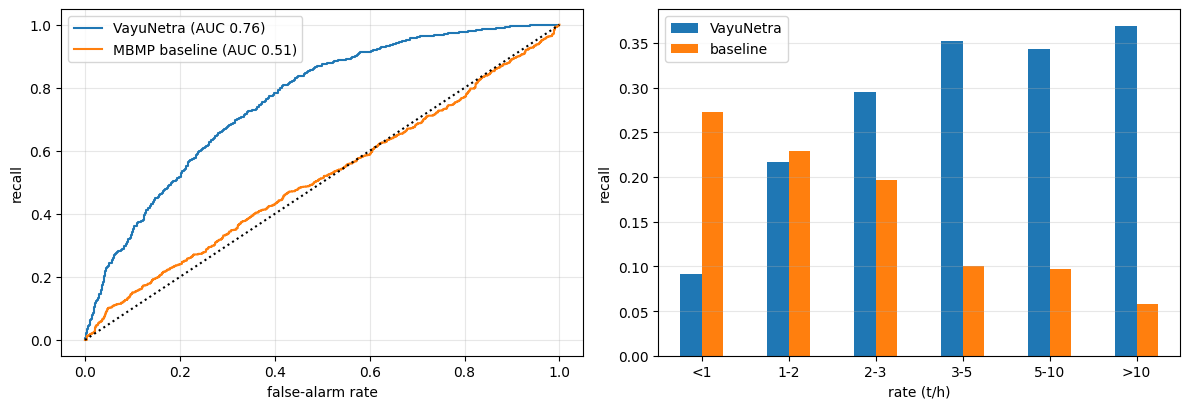

In [62]:
from sklearn.metrics import roc_curve, auc
yv = np.array([r["kind"] == "plume" for r in test_rows]); fig, ax = plt.subplots(1, 2, figsize=(12, 4.2)); ROC = {}
for name, key in [("VayuNetra", "ps"), ("MBMP baseline", "bs")]:
    fpr, tpr, _ = roc_curve(yv, [r[key] for r in test_rows]); a = auc(fpr, tpr)
    ROC[name] = dict(auc=a, r5=np.interp(.05, fpr, tpr), r10=np.interp(.10, fpr, tpr), r20=np.interp(.20, fpr, tpr))
    ax[0].plot(fpr, tpr, label=f"{name} (AUC {a:.2f})")
print(pd.DataFrame(ROC).T.round(3).rename(columns={"r5": "recall@5%FPR", "r10": "recall@10%FPR", "r20": "recall@20%FPR"}).to_string())
ax[0].plot([0, 1], [0, 1], "k:"); ax[0].set_xlabel("false-alarm rate"); ax[0].set_ylabel("recall"); ax[0].legend(); ax[0].grid(alpha=.3)
pl = [r for r in test_rows if r["kind"] == "plume"]
d = pd.DataFrame(dict(q=[meta.iloc[r["i"]]["detection:ch4_fluxrate"] for r in pl], unet=[r["ps"] > us_thr for r in pl], base=[r["bs"] > bs_thr for r in pl]))
d["rate (t/h)"] = pd.cut(d.q, [0, 1000, 2000, 3000, 5000, 10000, 1e9], labels=["<1", "1-2", "2-3", "3-5", "5-10", ">10"])
t = d.groupby("rate (t/h)", observed=True).agg(n=("q", "size"), VayuNetra=("unet", "mean"), baseline=("base", "mean"))
print("\nrecall by MARS emission rate:\n" + t.round(2).to_string())
t[["VayuNetra", "baseline"]].plot.bar(ax=ax[1], rot=0); ax[1].set_ylabel("recall"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_recall_by_rate.png", dpi=120); plt.show(); t.to_csv(OUT_DIR / "recall_by_rate.csv")

In [63]:
M_CH4, G, M_AIR = 0.01604, 9.81, 0.028964
def ppb_from_mbmp(m, key, amf):
    dd = np.linspace(0, 8000, 401); r11, r12 = band_ratios(dd, key, amf); s = 1 - r12 / r11; slope0 = (s[1] - s[0]) / (dd[1] - dd[0])
    return np.where(m >= 0, np.interp(m, s, dd), m / slope0)
def ime_kg(m, mask, key, amf, elev):
    n_air = 101325 * math.exp(-elev / 8434.0) / (G * M_AIR)
    return float((ppb_from_mbmp(m, key, amf)[mask] * 1e-9 * n_air * M_CH4).sum() * PIX_M ** 2), math.sqrt(mask.sum() * PIX_M ** 2)
cal = []
for k in tqdm(range(60 if QUICK_RUN else 400), desc="calibrating"):
    i = VAL[k % len(VAL)]; rng_ = np.random.default_rng(50_000 + k); g = GEOM[i]
    q = float(np.exp(rng_.uniform(np.log(2000), np.log(15000)))); x, y, m, info = synth_item(i, rng_, q=q)
    msk = binary_dilation(predict(x)[0] > 0.5, iterations=2)
    if msk.sum() < MIN_PLUME_PX: continue
    ime, L = ime_kg(m, msk, g["key"], g["amf"], g["elev"]); cal.append(dict(q=q, ws=BANK_META[info["j"], 0], ime=ime, L=L))
from scipy.optimize import nnls
cal = pd.DataFrame(cal)
cal["u_req"] = cal.q * cal.L / (3600 * cal.ime.clip(lower=1e-6))                  # wind speed each synthetic plume "needs"
ok = cal.u_req.between(cal.u_req.quantile(.05), cal.u_req.quantile(.95))          # drop truncated / overgrown masks
(a_cal, b_cal), _ = nnls(np.stack([cal.ws[ok].values, np.ones(ok.sum())], 1), cal.u_req[ok].values)
if a_cal < 0.1: a_cal, b_cal = 0.33, 0.45                                          # fallback: Varon et al. 2021 Sentinel-2 values
cal["q_est"] = 3600 * (a_cal * cal.ws + b_cal) * cal.ime / cal.L
real = []
for r in pl:
    g = GEOM[r["i"]]; msk = binary_dilation(r["prob"] > 0.5, iterations=2); u10 = math.hypot(g["u"], g["v"])
    if msk.sum() < MIN_PLUME_PX or u10 < 1.5: continue
    ime, L = ime_kg(r["m"], msk, g["key"], g["amf"], g["elev"])
    real.append(dict(q_mars=meta.iloc[r["i"]]["detection:ch4_fluxrate"], q_est=3600 * (a_cal * u10 + b_cal) * ime / max(L, 1)))
real = pd.DataFrame(real)
w50 = lambda d, c: float(np.mean(np.abs(d.q_est / d[c] - 1) <= .5)) if len(d) else float("nan")
print(f"U_eff = {a_cal:.3f}*U10 + {b_cal:.3f} | within ±50%: synthetic {w50(cal,'q'):.0%} (n={len(cal)}), real vs MARS {w50(real,'q_mars'):.0%} (n={len(real)})")
if len(real): print(f"median ratio VayuNetra/MARS on real plumes: {np.median(real.q_est / real.q_mars):.2f}")

calibrating: 100%|██████████| 400/400 [00:31<00:00, 12.65it/s]


U_eff = 0.140*U10 + 1.111 | within ±50%: synthetic 72% (n=380), real vs MARS 58% (n=839)
median ratio VayuNetra/MARS on real plumes: 1.02


In [64]:
import ee, math, time, datetime as dt
import numpy as np, pandas as pd
from pyproj import Transformer
from scipy.ndimage import binary_dilation
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

GEE_PROJECT = "gen-lang-client-0706669487"                       # Cloud project with Earth Engine enabled
try: ee.Initialize(project=GEE_PROJECT)                   # reuses saved token, no re-login
except Exception: ee.Authenticate(auth_mode="notebook"); ee.Initialize(project=GEE_PROJECT)

SITES = {"Ghazipur (Delhi)": (28.6247, 77.3272, 210), "Bhalswa (Delhi)": (28.7406, 77.1582, 215),
         "Okhla (Delhi)": (28.5125, 77.2835, 205), "Deonar (Mumbai)": (19.0717, 72.9278, 10),
         "Pirana (Ahmedabad)": (22.9762, 72.5656, 50)}
START, END, MAX_CLOUD, N_REF, MAX_PASSES = "2024-01-01", "2025-12-31", 30, 4, 80
S2_BANDS = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B10","B11","B12"]
HALF = CHIP * 10 // 2
CHIP_DIR = OUT_DIR / "india_chips"; CHIP_DIR.mkdir(exist_ok=True)

def run_site(img13, ref_swir, sza, vza, u10, sensor="S2A", elev=200.0):
    m = mbmp(img13[B["swir1"]], img13[B["swir2"]], ref_swir); prob, ps = predict(make_input(img13, ref_swir, m))
    msk = binary_dilation(prob > 0.5, iterations=2)
    out = dict(scene_score=round(ps, 3), detected=bool(ps > us_thr), plume_px=int((prob > .5).sum()), q_kgph=None)
    if out["detected"] and msk.sum() >= MIN_PLUME_PX and u10 >= 1.5:
        ime, L = ime_kg(m, msk, lut_key(sensor), amf_of(sza, vza), elev); out["q_kgph"] = round(3600 * (a_cal * u10 + b_cal) * ime / max(L, 1))
    return prob, out

def grid(lat, lon):
    epsg = (32600 if lat >= 0 else 32700) + int((lon + 180) // 6) + 1
    x, y = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True).transform(lon, lat)
    return {"dimensions": {"width": CHIP, "height": CHIP}, "crsCode": f"EPSG:{epsg}",
            "affineTransform": {"scaleX": 10, "shearX": 0, "translateX": x - HALF, "shearY": 0, "scaleY": -10, "translateY": y + HALF}}

def fetch(img_id, g):
    f = CHIP_DIR / f"{img_id.split('/')[-1]}_{g['affineTransform']['translateX']:.0f}_{g['affineTransform']['translateY']:.0f}.npy"
    if f.exists(): return np.load(f)
    err = None
    for k in range(3):
        try:
            a = ee.data.computePixels({"expression": ee.Image(img_id).select(S2_BANDS), "fileFormat": "NUMPY_NDARRAY", "grid": g})
            x = np.stack([a[b] for b in S2_BANDS]).astype("float32") / 10000; np.save(f, x); return x
        except Exception as e: err = e; time.sleep(2 * (k + 1))
    print("fetch failed", img_id, repr(err)[:120]); return None

def usable(x):
    if x is None or not np.isfinite(x).all() or (x[B["swir2"]] > 0).mean() < 0.99: return False
    return ((x[B["blue"]] > 0.25) | (x[10] > 0.012)).mean() < 0.05          # blue = cloud, B10 = cirrus

def u10_at(t_ms, lat, lon):
    try:
        t = ee.Date(t_ms); im = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterDate(t.advance(-30, "minute"), t.advance(90, "minute")).first()
        d = im.select(["u_component_of_wind_10m", "v_component_of_wind_10m"]).reduceRegion(ee.Reducer.first(), ee.Geometry.Point(lon, lat), 11132).getInfo()
        return math.hypot(d["u_component_of_wind_10m"], d["v_component_of_wind_10m"])
    except Exception: return float("nan")

rows, KEEP = [], {}
for site, (lat, lon, elev) in SITES.items():
    g = grid(lat, lon)
    lst = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED").filterBounds(ee.Geometry.Point(lon, lat)).filterDate(START, END)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .reduceColumns(ee.Reducer.toList(5), ["system:index", "system:time_start", "SPACECRAFT_NAME",
                                                 "MEAN_SOLAR_ZENITH_ANGLE", "MEAN_INCIDENCE_ZENITH_ANGLE_B12"]).get("list").getInfo())
    P = pd.DataFrame(lst, columns=["idx", "t", "sat", "sza", "vza"]).dropna()
    P["date"] = pd.to_datetime(P.t, unit="ms").dt.date
    P = P.drop_duplicates("date").sort_values("t").tail(MAX_PASSES).reset_index(drop=True)
    with ThreadPoolExecutor(8) as ex:
        P["chip"] = list(tqdm(ex.map(lambda s: fetch("COPERNICUS/S2_HARMONIZED/" + s, g), P.idx), total=len(P), desc=site))
    P = P[[usable(c) for c in P.chip]].reset_index(drop=True)
    print(f"{site}: {len(P)} clear passes")
    for k, r in P.iterrows():
        dd = np.array([(d - r.date).days for d in P.date]); cand = np.where((np.abs(dd) >= 10) & (np.abs(dd) <= 150))[0]
        if len(cand) < N_REF: continue
        refs = [(P.chip[j][B["swir1"]], P.chip[j][B["swir2"]]) for j in cand[np.argsort(np.abs(dd[cand]))[:N_REF]]]
        sat = "S2" + r.sat[-1]; u10 = float("nan")
        prob, out = run_site(r.chip, refs, r.sza, r.vza, u10, sat, elev)
        if out["detected"]:
            u10 = u10_at(int(r.t), lat, lon); prob, out = run_site(r.chip, refs, r.sza, r.vza, u10, sat, elev)
            KEEP[(site, r.date)] = (r.chip[[B["red"], B["green"], B["blue"]]], mbmp(r.chip[B["swir1"]], r.chip[B["swir2"]], refs), prob)
        rows.append(dict(site=site, date=r.date, sat=sat, u10=round(u10, 2) if np.isfinite(u10) else None, **out))
    del P
res = pd.DataFrame(rows); res.to_csv(OUT_DIR / "india_scan.csv", index=False)
print(res.groupby("site").detected.agg(["size", "sum"]).rename(columns={"size": "passes", "sum": "detections"}))

Ghazipur (Delhi): 100%|██████████| 80/80 [00:00<00:00, 4223.50it/s]


Ghazipur (Delhi): 69 clear passes


Bhalswa (Delhi): 100%|██████████| 80/80 [00:00<00:00, 4721.85it/s]


Bhalswa (Delhi): 70 clear passes


Okhla (Delhi): 100%|██████████| 80/80 [00:00<00:00, 4995.67it/s]


Okhla (Delhi): 70 clear passes


Deonar (Mumbai): 100%|██████████| 80/80 [00:00<00:00, 4719.59it/s]


Deonar (Mumbai): 67 clear passes


Pirana (Ahmedabad): 100%|██████████| 80/80 [00:00<00:00, 5366.39it/s]


Pirana (Ahmedabad): 64 clear passes
                    passes  detections
site                                  
Bhalswa (Delhi)         70           2
Deonar (Mumbai)         67           3
Ghazipur (Delhi)        69           3
Okhla (Delhi)           70           5
Pirana (Ahmedabad)      64           1


                    passes  detections  median_kgph  det_rate  tCO2e_per_yr_if_sustained
site                                                                                    
Bhalswa (Delhi)         70           2      17233.5      0.03                  4076000.0
Deonar (Mumbai)         67           3      25534.0      0.04                  6039000.0
Ghazipur (Delhi)        69           3      16835.0      0.04                  3982000.0
Okhla (Delhi)           70           5      20705.0      0.07                  4897000.0
Pirana (Ahmedabad)      64           1       4498.0      0.02                  1064000.0


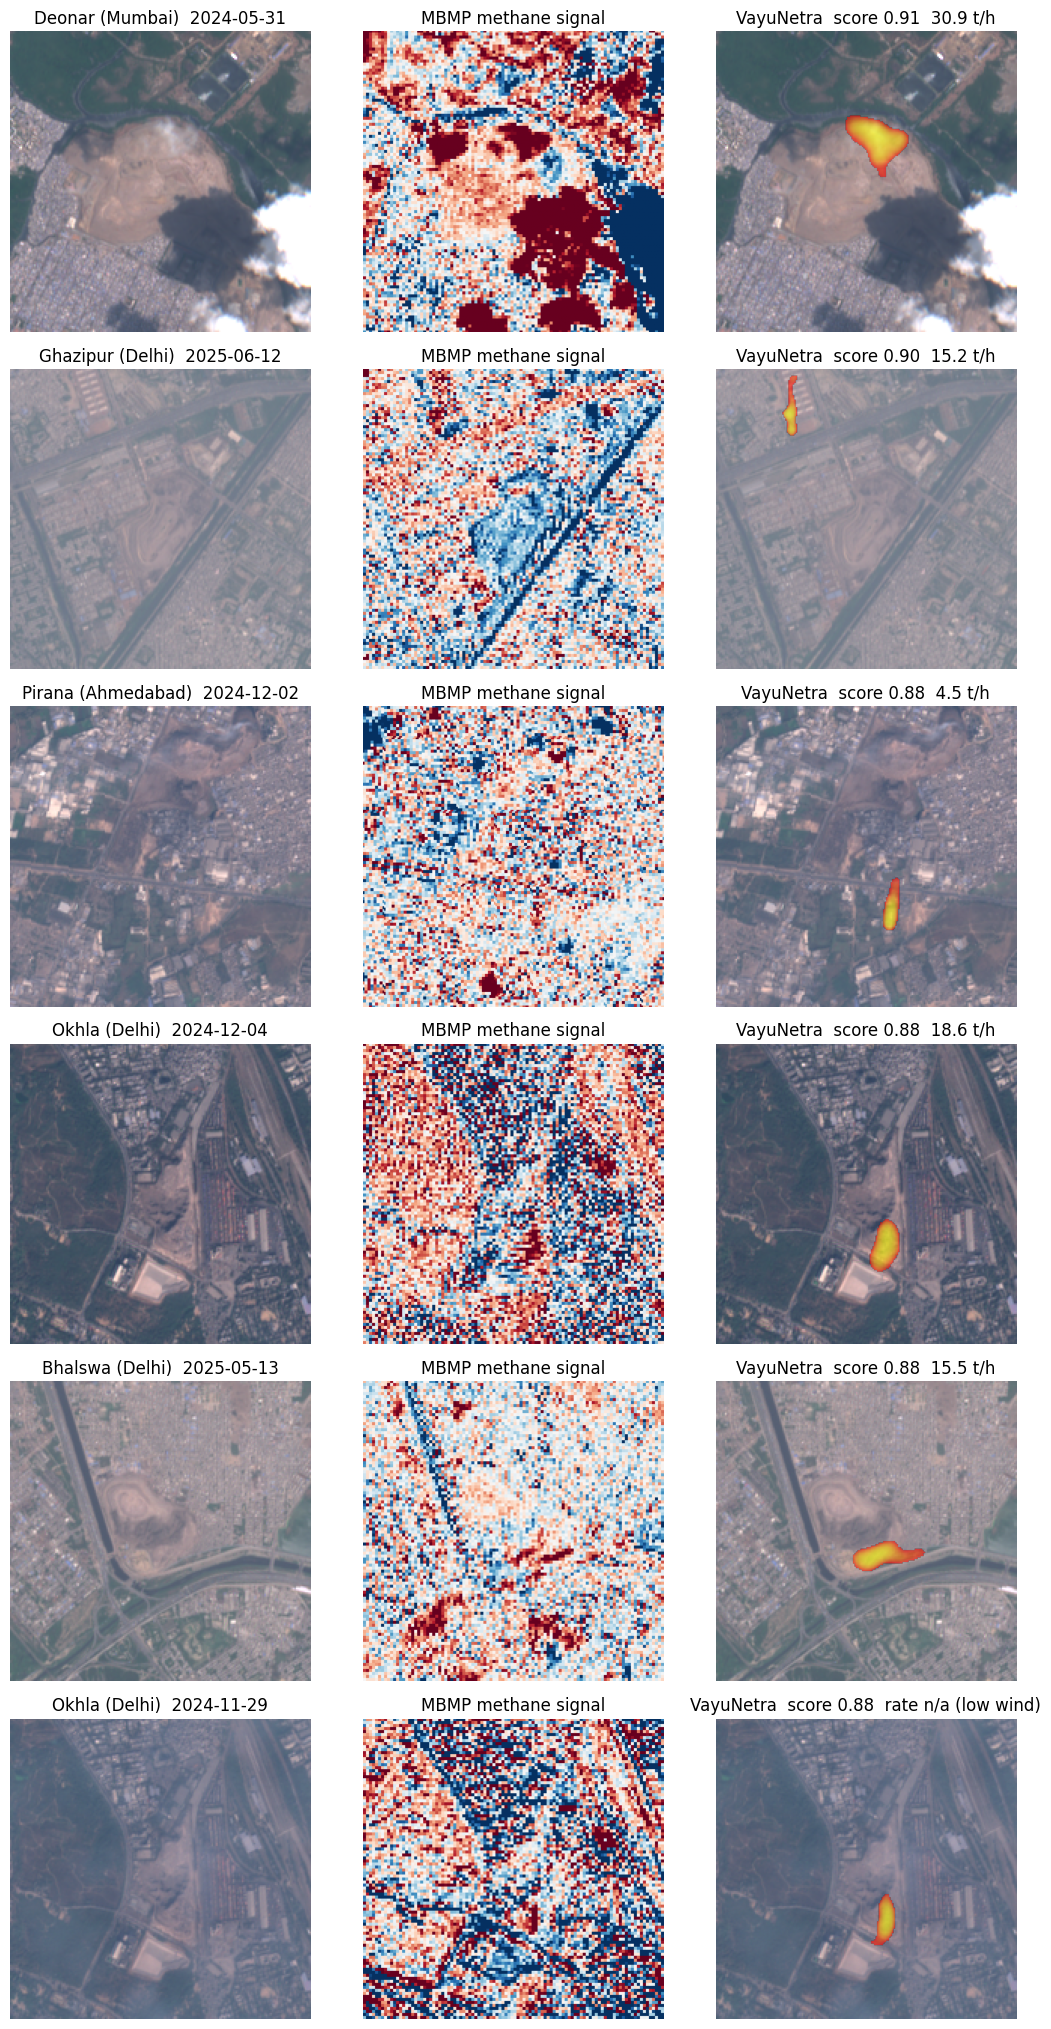

In [66]:
summ = res.groupby("site").agg(passes=("date", "size"), detections=("detected", "sum"), median_kgph=("q_kgph", "median"))
summ["det_rate"] = (summ.detections / summ.passes).round(2)
summ["tCO2e_per_yr_if_sustained"] = (summ.median_kgph * 8.76 * 27.0).round(-3)   # kg/h → t/yr × GWP100 (biogenic CH4, AR6)
print(summ.to_string())

det = res[res.detected].sort_values("scene_score", ascending=False).head(6)
if len(det):
    fig, ax = plt.subplots(len(det), 3, figsize=(11, 3.4 * len(det)), squeeze=False)
    for a, (_, r) in zip(ax, det.iterrows()):
        rgb, m, prob = KEEP[(r.site, r.date)]; img = np.clip(np.moveaxis(rgb, 0, -1) * 3.5, 0, 1)
        a[0].imshow(img); a[0].set_title(f"{r.site}  {r.date}")
        a[1].imshow(m, cmap="RdBu_r", vmin=-0.05, vmax=0.05); a[1].set_title("MBMP methane signal")
        a[2].imshow(img); a[2].imshow(np.ma.masked_less(prob, 0.5), cmap="autumn", alpha=0.6)
        a[2].set_title(f"VayuNetra  score {r.scene_score:.2f}  " + (f"{r.q_kgph/1000:.1f} t/h" if pd.notna(r.q_kgph) else "rate n/a (low wind)"))
        for b in a: b.axis("off")
    plt.tight_layout(); plt.savefig(OUT_DIR / "india_detections.png", dpi=150); plt.show()
else: print("no detections above threshold, so try MAX_PASSES=150 or lower us_thr to 0.7 for a candidate list")

Ghazipur control: https://www.google.com/maps/@28.669700000000002,77.3272,1500m/data=!3m1!1e3
Bhalswa control: https://www.google.com/maps/@28.785600000000002,77.1582,1500m/data=!3m1!1e3
Okhla control: https://www.google.com/maps/@28.5575,77.2835,1500m/data=!3m1!1e3
Deonar control: https://www.google.com/maps/@19.1167,72.9278,1500m/data=!3m1!1e3
Pirana control: https://www.google.com/maps/@23.0212,72.5656,1500m/data=!3m1!1e3


Pirana control: 100%|██████████| 80/80 [00:00<00:00, 5135.91it/s]


                             passes  detections  verified  median_kgph_verified  det_rate  verified_rate  tCO2e_yr_at_median_rate
kind     site                                                                                                                    
control  Bhalswa control         73           0         0                   NaN     0.000          0.000                      NaN
         Deonar control          65           0         0                   NaN     0.000          0.000                      NaN
         Ghazipur control        68           0         0                   NaN     0.000          0.000                      NaN
         Okhla control           69           0         0                   NaN     0.000          0.000                      NaN
         Pirana control          59           0         0                   NaN     0.000          0.000                      NaN
landfill Bhalswa (Delhi)         70           2         2               17233.5     0.029 

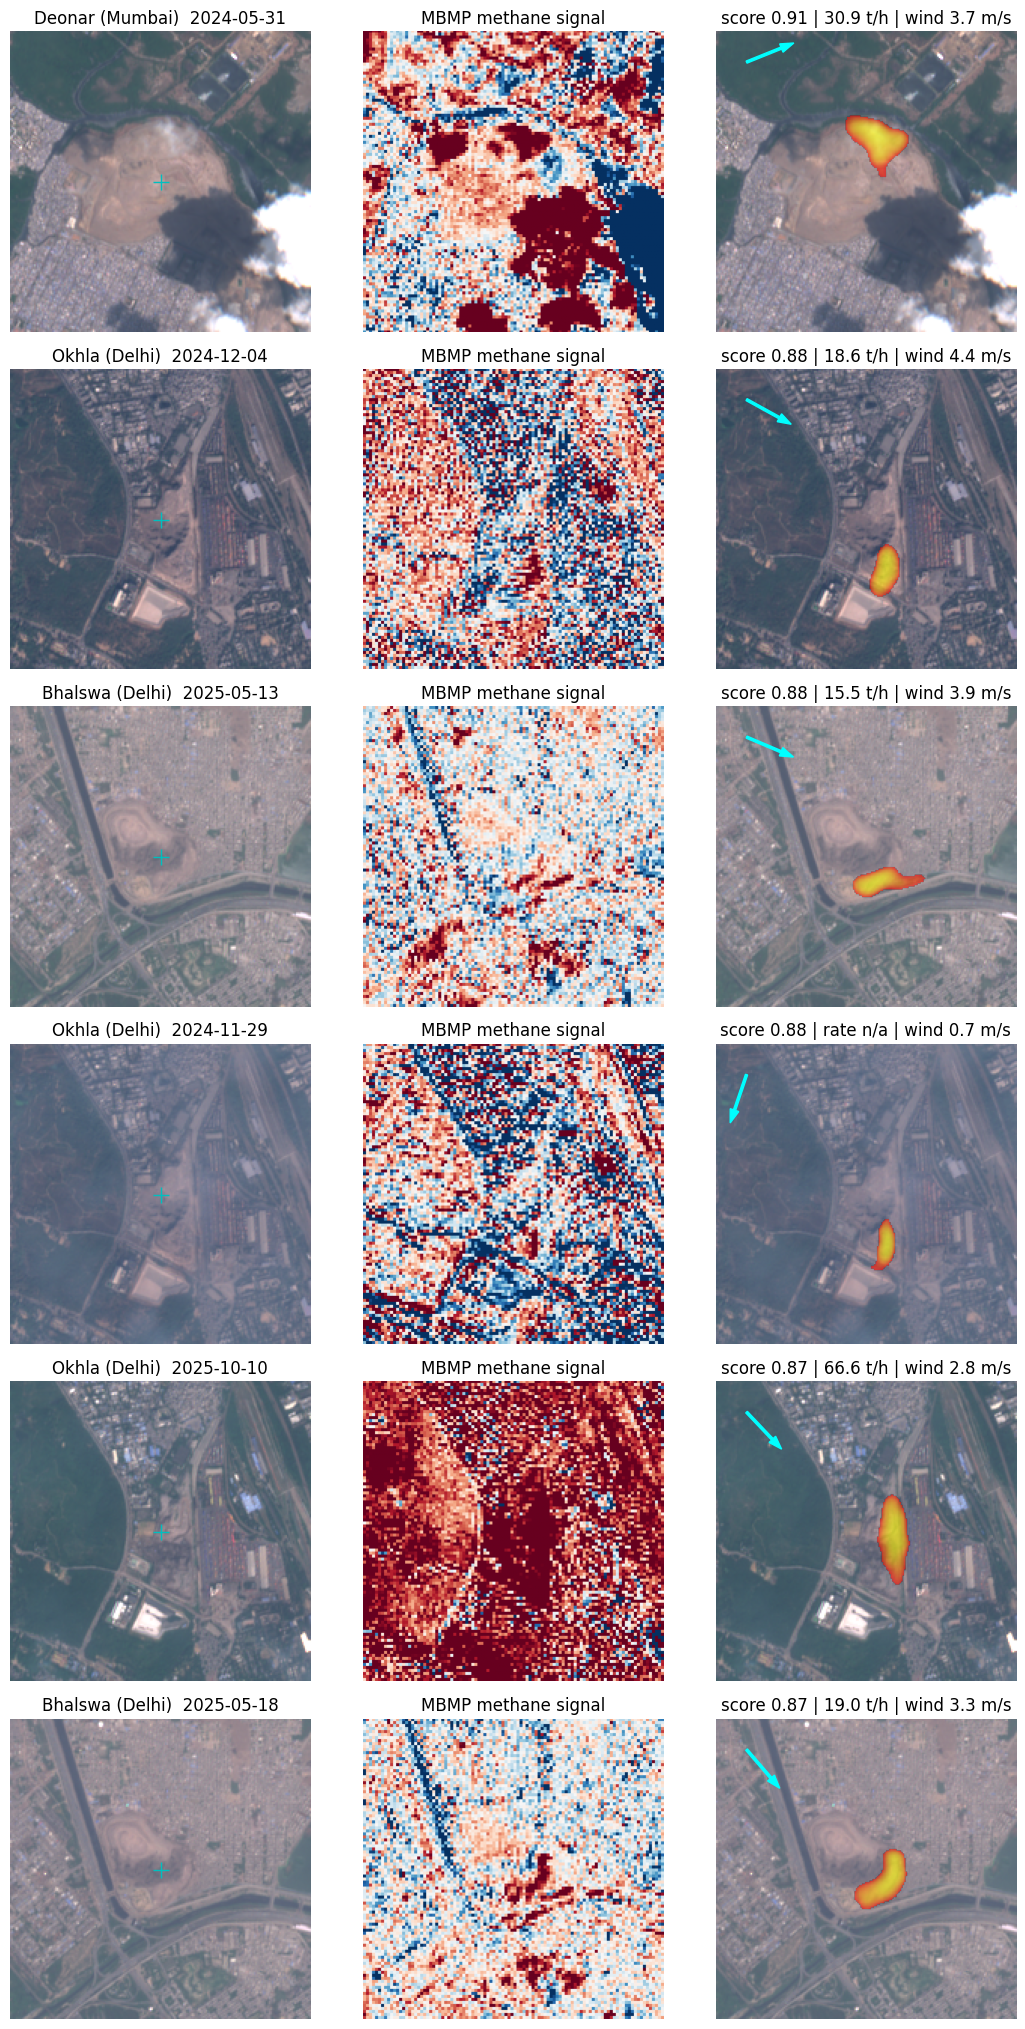

In [67]:
# Cell 25 — Control sites + plume sanity checks (source at the mound, pointing downwind)
import matplotlib.pyplot as plt

def wind_uv(t_ms, lat, lon):
    try:
        t = ee.Date(t_ms); im = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterDate(t.advance(-30, "minute"), t.advance(90, "minute")).first()
        d = im.select(["u_component_of_wind_10m", "v_component_of_wind_10m"]).reduceRegion(ee.Reducer.first(), ee.Geometry.Point(lon, lat), 11132).getInfo()
        return float(d["u_component_of_wind_10m"]), float(d["v_component_of_wind_10m"])
    except Exception: return float("nan"), float("nan")

def plume_check(prob, u, v, max_src_m=500, max_angle=60):
    m = prob > 0.5
    if m.sum() < MIN_PLUME_PX or not np.isfinite(u): return dict(src_dist_m=None, wind_angle=None, verified=False)
    rr, cc = np.nonzero(m); c0 = CHIP / 2
    src = float(np.sqrt((rr - c0) ** 2 + (cc - c0) ** 2).min() * 10)                  # nearest plume pixel to the site centre
    dx, dy = (cc.mean() - c0) * 10, -(rr.mean() - c0) * 10                            # plume centroid offset (east, north)
    ang = float(np.degrees(np.arccos(np.clip((dx * u + dy * v) / (math.hypot(dx, dy) * math.hypot(u, v) + 1e-9), -1, 1))))
    return dict(src_dist_m=round(src), wind_angle=round(ang), verified=bool(src <= max_src_m and ang <= max_angle))

def scan(sites, kind):
    out_rows, keep = [], {}
    for site, (lat, lon, elev) in sites.items():
        g = grid(lat, lon)
        lst = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED").filterBounds(ee.Geometry.Point(lon, lat)).filterDate(START, END)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
               .reduceColumns(ee.Reducer.toList(5), ["system:index", "system:time_start", "SPACECRAFT_NAME",
                                                     "MEAN_SOLAR_ZENITH_ANGLE", "MEAN_INCIDENCE_ZENITH_ANGLE_B12"]).get("list").getInfo())
        P = pd.DataFrame(lst, columns=["idx", "t", "sat", "sza", "vza"]).dropna()
        P["date"] = pd.to_datetime(P.t, unit="ms").dt.date
        P = P.drop_duplicates("date").sort_values("t").tail(MAX_PASSES).reset_index(drop=True)
        with ThreadPoolExecutor(8) as ex:
            P["chip"] = list(tqdm(ex.map(lambda s: fetch("COPERNICUS/S2_HARMONIZED/" + s, g), P.idx), total=len(P), desc=site))
        P = P[[usable(c) for c in P.chip]].reset_index(drop=True)
        for k, r in P.iterrows():
            dd = np.array([(d - r.date).days for d in P.date]); cand = np.where((np.abs(dd) >= 10) & (np.abs(dd) <= 150))[0]
            if len(cand) < N_REF: continue
            refs = [(P.chip[j][B["swir1"]], P.chip[j][B["swir2"]]) for j in cand[np.argsort(np.abs(dd[cand]))[:N_REF]]]
            sat = "S2" + r.sat[-1]
            prob, out = run_site(r.chip, refs, r.sza, r.vza, float("nan"), sat, elev)
            chk = dict(src_dist_m=None, wind_angle=None, verified=False); u = v = float("nan")
            if out["detected"]:
                u, v = wind_uv(int(r.t), lat, lon)
                prob, out = run_site(r.chip, refs, r.sza, r.vza, math.hypot(u, v), sat, elev)
                chk = plume_check(prob, u, v)
                keep[(site, r.date)] = (r.chip[[B["red"], B["green"], B["blue"]]], mbmp(r.chip[B["swir1"]], r.chip[B["swir2"]], refs), prob, u, v)
            out_rows.append(dict(kind=kind, site=site, date=r.date, u=u, v=v, **out, **chk))
        del P
    return out_rows, keep

CONTROLS = {f"{s.split(' (')[0]} control": (la + 0.045, lo, el) for s, (la, lo, el) in SITES.items()}   # ~5 km north, no landfill
for s, (la, lo, _) in CONTROLS.items(): print(f"{s}: https://www.google.com/maps/@{la},{lo},1500m/data=!3m1!1e3")
r1, k1 = scan(SITES, "landfill"); r2, k2 = scan(CONTROLS, "control")
full = pd.DataFrame(r1 + r2); KEEP = {**k1, **k2}; full.to_csv(OUT_DIR / "india_scan_verified.csv", index=False)

summ = full.groupby(["kind", "site"]).agg(passes=("date", "size"), detections=("detected", "sum"), verified=("verified", "sum"),
                                          median_kgph_verified=("q_kgph", lambda s: s[full.loc[s.index, "verified"]].median()))
summ["det_rate"] = (summ.detections / summ.passes).round(3); summ["verified_rate"] = (summ.verified / summ.passes).round(3)
summ["tCO2e_yr_at_median_rate"] = (summ.median_kgph_verified * 8.76 * 27.0).round(-3)
print(summ.to_string())
tot = full.groupby("kind").agg(passes=("date", "size"), det=("detected", "sum"), ver=("verified", "sum"))
print("\nPOOLED:", {k: f"detected {r.det}/{r.passes} ({r.det/r.passes:.1%}), verified {r.ver}/{r.passes} ({r.ver/r.passes:.1%})" for k, r in tot.iterrows()})

ver = full[full.verified & (full.kind == "landfill")].sort_values("scene_score", ascending=False).head(6)
if len(ver):
    fig, ax = plt.subplots(len(ver), 3, figsize=(11, 3.4 * len(ver)), squeeze=False)
    for a, (_, r) in zip(ax, ver.iterrows()):
        rgb, m, prob, u, v = KEEP[(r.site, r.date)]; img = np.clip(np.moveaxis(rgb, 0, -1) * 3.5, 0, 1); c0 = CHIP / 2
        a[0].imshow(img); a[0].plot(c0, c0, "c+", ms=12); a[0].set_title(f"{r.site}  {r.date}")
        a[1].imshow(m, cmap="RdBu_r", vmin=-0.05, vmax=0.05); a[1].set_title("MBMP methane signal")
        a[2].imshow(img); a[2].imshow(np.ma.masked_less(prob, 0.5), cmap="autumn", alpha=0.6)
        sp = math.hypot(u, v); a[2].arrow(20, 20, 25 * u / sp, -25 * v / sp, color="cyan", width=1.5, head_width=6)
        a[2].set_title(f"score {r.scene_score:.2f} | " + (f"{r.q_kgph/1000:.1f} t/h" if pd.notna(r.q_kgph) else "rate n/a") + f" | wind {sp:.1f} m/s")
        for b in a: b.axis("off")
    plt.tight_layout(); plt.savefig(OUT_DIR / "india_verified.png", dpi=150); plt.show()
else: print("no verified landfill detections")

In [68]:
# Cell 26 — Physics check on every detection: methane (B12-only dimming, wind-aligned) vs surface change
def load_passes(lat, lon):
    g = grid(lat, lon)
    lst = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED").filterBounds(ee.Geometry.Point(lon, lat)).filterDate(START, END)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .reduceColumns(ee.Reducer.toList(5), ["system:index", "system:time_start", "SPACECRAFT_NAME",
                                                 "MEAN_SOLAR_ZENITH_ANGLE", "MEAN_INCIDENCE_ZENITH_ANGLE_B12"]).get("list").getInfo())
    P = pd.DataFrame(lst, columns=["idx", "t", "sat", "sza", "vza"]).dropna()
    P["date"] = pd.to_datetime(P.t, unit="ms").dt.date
    P = P.drop_duplicates("date").sort_values("t").tail(MAX_PASSES).reset_index(drop=True)
    P["chip"] = [fetch("COPERNICUS/S2_HARMONIZED/" + s, g) for s in P.idx]          # cached → instant
    return P[[usable(c) for c in P.chip]].reset_index(drop=True)

def band_change(tgt, ref, msk, ring):
    r = tgt / np.clip(ref, 1e-4, None) - 1
    return float(np.median(r[msk]) - np.median(r[ring]))                            # plume vs its surroundings

def physics_check(tgt, ref_chips, prob, u, v):
    ref = np.median(np.stack(ref_chips), 0); msk = prob > 0.5
    ring = binary_dilation(msk, iterations=15) & ~binary_dilation(msk, iterations=3)
    d = {b: band_change(tgt[i], ref[i], msk, ring) for b, i in [("B2", 1), ("B4", 3), ("B8", 7), ("B11", 11), ("B12", 12)]}
    vis = max(abs(d["B2"]), abs(d["B4"]), abs(d["B8"]))
    spectral_ok = d["B12"] < -0.01 and vis < 0.5 * abs(d["B12"]) and d["B11"] > 0.5 * d["B12"]
    rr, cc = np.nonzero(msk); X = np.stack([cc - cc.mean(), -(rr - rr.mean())]).astype(float)
    w, V = np.linalg.eigh(np.cov(X)); elong = math.sqrt(w[1] / max(w[0], 1e-6))
    axis_ang = math.degrees(math.acos(min(1, abs(V[0, 1] * u + V[1, 1] * v) / (math.hypot(u, v) + 1e-9))))
    aligned = elong < 2.0 or axis_ang <= 45                                          # compact blobs (low wind) pass
    return dict(dB12=round(d["B12"], 4), dB11=round(d["B11"], 4), dVisNIR=round(vis, 4), spectral_ok=spectral_ok,
                elong=round(elong, 1), axis_vs_wind=round(axis_ang), aligned=aligned, methane_confident=bool(spectral_ok and aligned))

ALL_SITES = {**SITES, **CONTROLS}; phys = []
for site in full[full.detected].site.unique():
    lat, lon, elev = ALL_SITES[site]; P = load_passes(lat, lon)
    for _, r in full[full.detected & (full.site == site)].iterrows():
        k = P.index[P.date == r.date]
        if not len(k): continue
        k = k[0]; dd = np.array([(d - r.date).days for d in P.date]); cand = np.where((np.abs(dd) >= 10) & (np.abs(dd) <= 150))[0]
        ref_chips = [P.chip[j] for j in cand[np.argsort(np.abs(dd[cand]))[:N_REF]]]
        prob = KEEP[(site, r.date)][2]
        phys.append(dict(kind=r.kind, site=site, date=r.date, score=r.scene_score, q_kgph=r.q_kgph, verified_geom=r.verified,
                         **physics_check(P.chip[k], ref_chips, prob, r.u, r.v)))
phys = pd.DataFrame(phys); phys.to_csv(OUT_DIR / "india_physics_check.csv", index=False)
print(phys.to_string(index=False))
print("\nmethane_confident:", phys.groupby("kind").methane_confident.agg(["sum", "size"]).to_dict("index"))

    kind               site       date  score  q_kgph  verified_geom    dB12    dB11  dVisNIR  spectral_ok  elong  axis_vs_wind  aligned  methane_confident
landfill   Ghazipur (Delhi) 2025-04-28  0.853 18441.0          False -0.1376 -0.0542   0.0673         True   14.4            59    False              False
landfill   Ghazipur (Delhi) 2025-06-12  0.901 15229.0          False -0.0797 -0.0506   0.0385        False    5.4            57    False              False
landfill   Ghazipur (Delhi) 2025-10-20  0.858     NaN          False -0.0970 -0.0752   0.1073        False    3.2            63    False              False
landfill    Bhalswa (Delhi) 2025-05-13  0.879 15499.0           True -0.0204 -0.0034   0.0224        False    2.9            30     True              False
landfill    Bhalswa (Delhi) 2025-05-18  0.873 18968.0           True -0.0338 -0.0172   0.0057        False    2.1            80    False              False
landfill      Okhla (Delhi) 2024-05-28  0.858  4913.0          F

Indian scenes: 674 | clean backgrounds: 660 | hard negatives: 13 | borderline: 2


India PoD: 100%|██████████| 6/6 [00:36<00:00,  6.08s/it]


       model  model_plus_physics
q                               
1000    0.00                0.00
2000    0.00                0.00
3000    0.00                0.00
5000    0.01                0.00
8000    0.06                0.01
12000   0.12                0.02
50% detection limit over Indian landfills: model nan t/h | model + physics check nan t/h


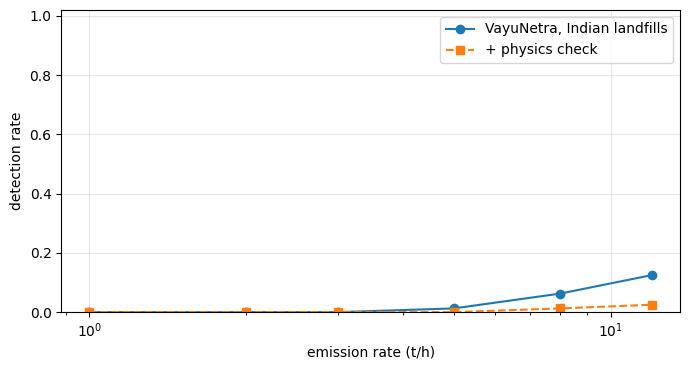

In [69]:
# Cell 27 — Indian scene set + detection limit over Indian landfills (synthetic plumes injected at the mound)
from scipy.ndimage import gaussian_filter
FLAGGED = set(zip(full.loc[full.detected, "site"], full.loc[full.detected, "date"]))
BORDERLINE = {("Bhalswa (Delhi)", dt.date(2025, 2, 22)), ("Bhalswa (Delhi)", dt.date(2025, 5, 18))}

def build_india(sites, kind):
    out = []
    for site, (lat, lon, elev) in sites.items():
        P = load_passes(lat, lon)
        for k, r in P.iterrows():
            dd = np.array([(d - r.date).days for d in P.date]); cand = np.where((np.abs(dd) >= 10) & (np.abs(dd) <= 150))[0]
            if len(cand) < N_REF: continue
            out.append(dict(kind=kind, site=site, date=r.date, elev=elev, key=lut_key("S2" + r.sat[-1]), sza=float(r.sza), vza=float(r.vza),
                            tgt=P.chip[k], refs=[P.chip[j] for j in cand[np.argsort(np.abs(dd[cand]))[:N_REF]]]))
    return out

INDIA = build_india(SITES, "landfill") + build_india(CONTROLS, "control")
CLEAN = [s for s in INDIA if (s["site"], s["date"]) not in FLAGGED]
HARD = [s for s in INDIA if (s["site"], s["date"]) in FLAGGED and (s["site"], s["date"]) not in BORDERLINE]
BORDER = [s for s in INDIA if (s["site"], s["date"]) in BORDERLINE]
print(f"Indian scenes: {len(INDIA)} | clean backgrounds: {len(CLEAN)} | hard negatives: {len(HARD)} | borderline: {len(BORDER)}")

def surface_change(tgt, rng):
    """Fake landfill surface change (burn, moisture, fresh dumping): all bands shift together inside a blob."""
    blob = gaussian_filter(rng.normal(size=(CHIP, CHIP)), rng.uniform(4, 12)); blob = blob > np.quantile(blob, rng.uniform(0.85, 0.97))
    blob = gaussian_filter(blob.astype("float32"), 1.5)
    dv = rng.uniform(-0.15, 0.15); d = dv * rng.uniform(0.7, 1.3, 13)
    d[B["swir1"]] = dv * rng.uniform(0.5, 1.5); d[B["swir2"]] = dv * rng.uniform(0.5, 1.8)
    return (tgt * (1 + d[:, None, None] * blob[None])).astype("float32")

def india_input(s, rng, q=None, surface=False, src=None):
    tgt = s["tgt"].copy(); refs = [(r[B["swir1"]], r[B["swir2"]]) for r in s["refs"]]
    if surface: tgt = surface_change(tgt, rng)
    mask = np.zeros((CHIP, CHIP), "float32"); u = v = 0.0
    if q is not None:
        sigma = robust_sigma(mbmp(tgt[B["swir1"]], tgt[B["swir2"]], refs))
        theta = rng.uniform(0, 2 * math.pi); j = pick_bank(rng, s["sza"])
        enh = place_plume(j, q, theta, src if src is not None else (rng.uniform(50, 150), rng.uniform(50, 150)))
        r11, r12 = band_ratios(enh, s["key"], amf_of(s["sza"], s["vza"])); tgt[B["swir1"]] *= r11; tgt[B["swir2"]] *= r12
        mask = (((1 - r12 / r11) > LABEL_K * sigma) & (enh > 100)).astype("float32")
        if mask.sum() < MIN_PLUME_PX: mask[:] = 0
        u, v = math.cos(theta), math.sin(theta)
    m = mbmp(tgt[B["swir1"]], tgt[B["swir2"]], refs)
    return make_input(tgt, refs, m), mask, m, tgt, (u, v)

def limit_at(qs, pods, level=0.5):
    if pods[0] >= level: return qs[0]
    for (q1, p1), (q2, p2) in zip(zip(qs, pods), zip(qs[1:], pods[1:])):
        if p1 < level <= p2: return math.exp(math.log(q1) + (level - p1) / (p2 - p1) * (math.log(q2) - math.log(q1)))
    return float("nan")

def india_pod(sites, qs=(1000, 2000, 3000, 5000, 8000, 12000), n_per=80, seed=70_000):
    pool = [s for s in CLEAN if s["site"] in sites]; rows_ = []
    for q in tqdm(qs, desc="India PoD"):
        for k in range(n_per):
            rng_ = np.random.default_rng(seed + 97 * q + k); s = pool[rng_.integers(len(pool))]; c0 = CHIP / 2
            x, y, m, tgt, (u, v) = india_input(s, rng_, q=q, src=(c0 + rng_.uniform(-30, 30), c0 + rng_.uniform(-30, 30)))
            prob, ps = predict(x); det = ps > us_thr
            conf = bool(det and (prob > 0.5).sum() >= MIN_PLUME_PX and physics_check(tgt, s["refs"], prob, u, v)["methane_confident"])
            rows_.append(dict(q=q, site=s["site"], det=det, confirmed=conf))
    return pd.DataFrame(rows_).groupby("q").agg(model=("det", "mean"), model_plus_physics=("confirmed", "mean"))

POD_SITES = set(SITES)                                   # after Stage B: POD_SITES = {"Bhalswa (Delhi)"} (held-out site)
pod_in = india_pod(POD_SITES); qs_ = list(pod_in.index)
print(pod_in.round(2).to_string())
print(f"50% detection limit over Indian landfills: model {limit_at(qs_, pod_in.model.tolist())/1000:.1f} t/h | "
      f"model + physics check {limit_at(qs_, pod_in.model_plus_physics.tolist())/1000:.1f} t/h")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(np.array(qs_) / 1000, pod_in.model, "o-", label="VayuNetra, Indian landfills")
ax.plot(np.array(qs_) / 1000, pod_in.model_plus_physics, "s--", label="+ physics check")
if "pod" in globals() and "QS" in globals(): ax.plot(np.array(QS) / 1000, pod["VayuNetra"], "^:", c="gray", label="VayuNetra, MethaneSET test sites")
ax.set_xscale("log"); ax.set_xlabel("emission rate (t/h)"); ax.set_ylabel("detection rate"); ax.set_ylim(0, 1.02); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "pod_india.png", dpi=150); plt.show(); pod_in.to_csv(OUT_DIR / "pod_india.csv")

In [70]:
# Cell 28 — Stage B: fine-tune on Indian backgrounds (injected plumes + surface-change hard negatives), Bhalswa held out
from sklearn.metrics import roc_auc_score
shutil.copy(OUT_DIR / "best.pt", OUT_DIR / "best_stageA.pt")
HOLD = {"Bhalswa (Delhi)", "Bhalswa control"}
TR_CLEAN = [s for s in CLEAN if s["site"] not in HOLD]; TR_HARD = [s for s in HARD if s["site"] not in HOLD]
HO_CLEAN = [s for s in CLEAN if s["site"] in HOLD]; HO_HARD = [s for s in HARD if s["site"] in HOLD]
print(f"train: {len(TR_CLEAN)} clean + {len(TR_HARD)} hard | held-out: {len(HO_CLEAN)} clean + {len(HO_HARD)} hard + {len(BORDER)} borderline")

class IndiaSet(Dataset):
    def __init__(self, clean, hard, n, p_inject=0.5, p_hard=0.15, p_surf=0.25):
        self.clean, self.hard, self.n, self.pi, self.ph, self.ps = clean, hard, n, p_inject, p_hard, p_surf
    def __len__(self): return self.n
    def __getitem__(self, k):
        rng = np.random.default_rng()
        if self.hard and rng.random() < self.ph:
            x, y = india_input(self.hard[rng.integers(len(self.hard))], rng)[:2]
        else:
            s = self.clean[rng.integers(len(self.clean))]; r = rng.random()
            if r < self.pi: x, y = india_input(s, rng, q=float(np.exp(rng.uniform(np.log(500), np.log(15000)))), surface=rng.random() < 0.3)[:2]
            elif r < self.pi + self.ps: x, y = india_input(s, rng, surface=True)[:2]
            else: x, y = india_input(s, rng)[:2]
        y0, x0 = rng.integers(0, CHIP - CROP + 1, 2); x, y = x[:, y0:y0 + CROP, x0:x0 + CROP], y[y0:y0 + CROP, x0:x0 + CROP]
        kk = int(rng.integers(4)); x, y = np.rot90(x, kk, (1, 2)), np.rot90(y, kk)
        if rng.random() < .5: x, y = x[:, :, ::-1], y[:, ::-1]
        return torch.from_numpy(np.ascontiguousarray(x, dtype=np.float16)), torch.from_numpy(np.ascontiguousarray(y, dtype=np.uint8))[None]

ds_b = ConcatDataset([PlumeSet(TRAIN, "real", len(TRAIN) // 2), PlumeSet(TRAIN, "synth", len(TRAIN), 0.6), IndiaSet(TR_CLEAN, TR_HARD, len(TRAIN))])
DL_B = ThreadLoader(ds_b, BATCH, True, True, workers=min(16, 2 * NW))

rng_h = np.random.default_rng(123); c0 = CHIP / 2          # fixed held-out Bhalswa evaluation set
HO_POS = [india_input(HO_CLEAN[k % len(HO_CLEAN)], rng_h, q=[2000, 3000, 5000, 8000][k % 4],
                      src=(c0 + rng_h.uniform(-30, 30), c0 + rng_h.uniform(-30, 30)))[0].astype(np.float16) for k in range(120)]
HO_NEG = [india_input(s, rng_h)[0].astype(np.float16) for s in HO_CLEAN]
HO_HN = [india_input(s, rng_h)[0].astype(np.float16) for s in HO_HARD]
HO_BL = [india_input(s, rng_h)[0].astype(np.float16) for s in BORDER]

@torch.no_grad()
def scene_scores(net, xs, bs=16):
    net.eval(); out = []
    for i in range(0, len(xs), bs):
        xb = torch.from_numpy(np.stack([np.pad(x.astype("float32"), ((0, 0), (PAD, PAD), (PAD, PAD)), mode="reflect") for x in xs[i:i + bs]]))
        xb = xb.to(DEVICE).to(memory_format=torch.channels_last)
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=DEVICE == "cuda"): s, _ = net(xb)
        out += scene_score(torch.sigmoid(s.float())[:, :, PAD:-PAD, PAD:-PAD]).cpu().tolist()
    return np.array(out)

def india_metrics(net):
    sp, sn, sh, sb = (scene_scores(net, X) for X in (HO_POS, HO_NEG, HO_HN, HO_BL))
    neg = np.r_[sn, sh]
    return dict(auc=roc_auc_score(np.r_[np.ones(len(sp)), np.zeros(len(neg))], np.r_[sp, neg]), pod=float((sp > us_thr).mean()),
                fa_clean=float((sn > us_thr).mean()), hard_rejected=f"{int((sh <= us_thr).sum())}/{len(sh)}", borderline=np.round(sb, 2).tolist())

EPOCHS_B = 25
model.load_state_dict(torch.load(OUT_DIR / "best_stageA.pt", map_location=DEVICE))
for p_ in model.parameters(): p_.requires_grad = True
g0, i0 = evaluate(model, VA_DL), india_metrics(model)
print(f"[stage A] val IoU {g0['iou']:.3f} F1 {g0['f1']:.2f} | India held-out: {i0}")
ema = AveragedModel(model, avg_fn=_ema_avg, use_buffers=True)
enc_ids = {id(p) for p in model.encoder.parameters()}
groups = [{"params": list(model.encoder.parameters()), "lr": LR_ENC * 0.3},
          {"params": [p for p in model.parameters() if id(p) not in enc_ids], "lr": LR_DEC * 0.3}]
opt = torch.optim.AdamW(groups, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in groups], total_steps=EPOCHS_B * len(DL_B), pct_start=0.15)
best_b, HIST_B = -1.0, []
for ep in range(EPOCHS_B):
    model.train(); t0 = time.time(); tot = 0.0
    for x, y in DL_B:
        x = x.to(DEVICE, non_blocking=True).float().to(memory_format=torch.channels_last); y = y.to(DEVICE, non_blocking=True).float()
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=DEVICE == "cuda"): seg, sc = model(x)
        loss = loss_fn(seg.float(), sc.float(), y)
        opt.zero_grad(set_to_none=True); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
        ema.update_parameters(model); tot += loss.item()
    ev, im = evaluate(ema.module, VA_DL), india_metrics(ema.module); score = ev["iou"] + ev["f1"] + im["auc"]
    HIST_B.append(dict(epoch=ep + 1, loss=tot / len(DL_B), **ev, **{k: v for k, v in im.items() if k != "borderline"}))
    star = score > best_b
    if star: best_b = score; torch.save(ema.module.state_dict(), OUT_DIR / "best_stageB.pt")
    print(f"[B] ep {ep+1}/{EPOCHS_B} loss {tot/len(DL_B):.3f} | val IoU {ev['iou']:.3f} F1 {ev['f1']:.2f} | India AUC {im['auc']:.3f} "
          f"PoD {im['pod']:.2f} FA {im['fa_clean']:.2f} hard rejected {im['hard_rejected']} borderline {im['borderline']} | {time.time()-t0:.0f}s" + ("  *" if star else ""))
model.load_state_dict(torch.load(OUT_DIR / "best_stageB.pt", map_location=DEVICE)); model.eval()
pd.DataFrame(HIST_B).to_csv(OUT_DIR / "history_stageB.csv", index=False)

train: 519 clean + 12 hard | held-out: 141 clean + 1 hard + 2 borderline
[stage A] val IoU 0.338 F1 0.82 | India held-out: {'auc': 0.511150234741784, 'pod': 0.06666666666666667, 'fa_clean': 0.06382978723404255, 'hard_rejected': '0/1', 'borderline': [0.84, 0.9]}
[B] ep 1/25 loss 1.568 | val IoU 0.318 F1 0.82 | India AUC 0.519 PoD 0.02 FA 0.01 hard rejected 1/1 borderline [0.4, 0.42] | 54s  *
[B] ep 2/25 loss 1.354 | val IoU 0.328 F1 0.81 | India AUC 0.521 PoD 0.01 FA 0.01 hard rejected 1/1 borderline [0.13, 0.11] | 52s  *
[B] ep 3/25 loss 1.271 | val IoU 0.318 F1 0.81 | India AUC 0.531 PoD 0.00 FA 0.00 hard rejected 1/1 borderline [0.15, 0.08] | 54s  *
[B] ep 4/25 loss 1.258 | val IoU 0.320 F1 0.81 | India AUC 0.527 PoD 0.00 FA 0.00 hard rejected 1/1 borderline [0.13, 0.08] | 52s
[B] ep 5/25 loss 1.275 | val IoU 0.327 F1 0.82 | India AUC 0.537 PoD 0.00 FA 0.00 hard rejected 1/1 borderline [0.38, 0.14] | 53s  *
[B] ep 6/25 loss 1.269 | val IoU 0.326 F1 0.81 | India AUC 0.544 PoD 0.00 FA 

In [72]:
# Cell 30 — Export the best model only: weights (fp32 + fp16) + model card + LUT + key results → one zip
import zipfile, hashlib, json, time, glob, os
from pathlib import Path
CKPT = OUT_DIR / "best.pt"                                            # model selected in Cell 17c
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)); model.eval()
EXP = OUT_DIR / "export_best"; shutil.rmtree(EXP, ignore_errors=True); EXP.mkdir()

sd = {k: v.detach().cpu() for k, v in model.state_dict().items()}
torch.save(sd, EXP / "vayunetra_best.pt")
torch.save({k: (v.half() if v.is_floating_point() else v) for k, v in sd.items()}, EXP / "vayunetra_best_fp16.pt")

card = dict(
    name="VayuNetra", checkpoint=CKPT.name, exported=time.strftime("%Y-%m-%d %H:%M"),
    arch="smp.Unet('resnet50', decoder_attention_type='scse', aux_params=dict(classes=1, pooling='avg', dropout=0.2))",
    in_channels=int(13 + N_EXTRA), classes=1, pretrained_encoder="SSL4EO-S12 ResNet-50 MoCo (torchgeo), conv1 widened 13→17",
    inputs="13 S2 L1C TOA bands (DN/10000, harmonized; order B1..B8,B8A,B9..B12) + ref B11, ref B12 (median of 4 clean passes) "
           "+ clip(MBMP/0.02,±10) + clip(robust z of MBMP,±8)",
    chip=int(CHIP), pad=int(PAD), min_plume_px=int(MIN_PLUME_PX),
    scene_score=f"mean of top-{MIN_PLUME_PX} pixel probabilities, 4-flip TTA", scene_threshold=float(us_thr),
    ime=dict(a=float(a_cal), b=float(b_cal), formula="Q[kg/h] = 3600*(a*U10+b)*IME[kg]/L[m]"),
    physics_check="methane if B12 dims >1%, B11 dims <half of B12, visible/NIR change <half of B12; elongated plumes within 45° of wind",
    loss="positive-only Dice + balanced focal + top-k detection BCE + aux scene BCE")
if (OUT_DIR / "test_metrics.csv").exists(): card["test_metrics"] = pd.read_csv(OUT_DIR / "test_metrics.csv", index_col=0).round(3).to_dict("index")
json.dump(card, open(EXP / "model_card.json", "w"), indent=2, default=float)

for src in [RAW_DIR / "integrated_transmittances.json", OUT_DIR / "integrated_transmittances.json"]:
    if src.exists(): shutil.copy(src, EXP / "integrated_transmittances.json"); break
for f in ["test_metrics.csv", "roc_recall_by_rate.png", "pod_curve.png", "pod_india.png",
          "india_scan_verified.csv", "india_physics_check.csv", "india_verified.png"]:
    if (OUT_DIR / f).exists(): (EXP / "results").mkdir(exist_ok=True); shutil.copy(OUT_DIR / f, EXP / "results" / f)

(EXP / "README.md").write_text(f"""# VayuNetra — best model
Load:
```python
import torch, json, segmentation_models_pytorch as smp
card = json.load(open("model_card.json"))
model = smp.Unet("resnet50", encoder_weights=None, in_channels=card["in_channels"], classes=1,
                 decoder_attention_type="scse", aux_params=dict(classes=1, pooling="avg", dropout=0.2))
model.load_state_dict(torch.load("vayunetra_best.pt", map_location="cpu")); model.eval()
```
Detection: scene score > {float(us_thr):.3f}. Inputs, emission formula and physics check: see model_card.json.
fp16 copy (half size): vayunetra_best_fp16.pt → load, then model.float().
""")
sha = hashlib.sha256(open(EXP / "vayunetra_best.pt", "rb").read()).hexdigest()
(EXP / "SHA256.txt").write_text(f"{sha}  vayunetra_best.pt\n")

zip_path = Path(f"vayunetra_best_model_{time.strftime('%Y%m%d_%H%M')}.zip").resolve()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, allowZip64=True) as z:
    for p in EXP.rglob("*"):
        if p.is_file(): z.write(p, arcname=str(Path("vayunetra_best") / p.relative_to(EXP)))
    for nb in glob.glob("*.ipynb"): z.write(nb, arcname=f"vayunetra_best/notebook/{Path(nb).name}")
print(f"{zip_path.name}: {zip_path.stat().st_size/1e6:.0f} MB | sha256 {sha[:16]}…")
for p in sorted(EXP.rglob("*")):
    if p.is_file(): print(f"  {p.stat().st_size/1e6:7.1f} MB  {p.relative_to(EXP)}")
try:
    from google.colab import files as _c; _c.download(str(zip_path))
except ImportError:
    from IPython.display import FileLink, display; display(FileLink(os.path.relpath(zip_path)))
    print("If the link fails: Jupyter file browser → right-click", zip_path.name, "→ Download")

vayunetra_best_model_20261001_1401.zip: 197 MB | sha256 d09323ab3b23ffb6…
      0.0 MB  README.md
      0.0 MB  SHA256.txt
      0.1 MB  integrated_transmittances.json
      0.0 MB  model_card.json
      0.0 MB  results/india_physics_check.csv
      0.0 MB  results/india_scan_verified.csv
      3.5 MB  results/india_verified.png
      0.0 MB  results/pod_india.png
      0.1 MB  results/roc_recall_by_rate.png
      0.0 MB  results/test_metrics.csv
    135.8 MB  vayunetra_best.pt
     68.0 MB  vayunetra_best_fp16.pt


/workspace/vayunetra_best_model_20261001_1401.zip

If the link fails: Jupyter file browser → right-click vayunetra_best_model_20261001_1401.zip → Download
